# *Trabajo Practico N°2 - Laboratorio de Datos*

**Fecha:** 09/03/2026

# Limpieza de datos

In [ ]:
#!pip install formulaic

In [ ]:
import pandas as pd
import numpy as np
import seaborn.objects as so
from formulaic import Formula,model_matrix

#sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN,KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

## Ejercicio 1

Abrimos el archivo que vamos a estar usando:

In [ ]:
datos = pd.read_csv("usu_individual_T325.txt",sep=";")
datos.head()

/tmp/ipykernel_1179/2447183730.py:1: DtypeWarning: Columns (102) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv("usu_individual_T325.txt",sep=";")


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0


## Ejercicio 2

Vemos los valores que puede tomar la columna H15, para eliminar los datos de los individuos que no contestaron la encuesta.

In [ ]:
datos["H15"].value_counts()

,count
H15,
1,39999
0,4883
2,64


Segun el archivo del INDEC, nos indica que esta columna puede tomar como valor: "1" si se realizó la encuesta, "2" si no se realizó, y "0" no está detallado, pero lo podriamos tomar como un dato faltante.

Como en comparación la cantidad de datos que se tienen respecto a los que son faltantes es mucho mayor, podemos borrar, ademas de las filas que tengan 2 en esta columna, las que tengan 0. Por lo que solo nos quedamos con las filas que tengan "1" en "H15".

In [ ]:
datos_limpios = datos[datos["H15"]==1].copy()
datos_limpios.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
5,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,4,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
6,TQRMNOQSSHKLKRCDEIHJF00868831,2025,3,1,1,1,44,N,31,140,...,0,0,0,0,3.0,2.0,NaN,4.0,4.0,2.0


## Ejercicio 3

Nos quedamos solo con las columnas pedidas:

In [ ]:
datos_limpios = datos_limpios[[ "EMPLEO", "REGION", "MAS_500", "CH04", "CH03", "CH06", "CH07",
"CH09", "CH10", "NIVEL_ED", "ESTADO", "CAT_OCUP", "CAT_INAC", "SECTOR", "PP02B",
"PP02C1", "PP02C2", "PP02C3", "PP02C4", "PP02C5", "PP02C6", "PP02C7", "PP02C8",
"PP02D", "PP02F", "PP02G", "PP02H", "PP02I", "PP03C", "PP03D", "PP3E_TOT",
"PP3F_TOT", "PP03G", "PP03H", "PP04A", "PP04A1", "PP04B1", "PP04B2",
"PP04B3_ANO", "PP04C", "PP03I", "PP03J", "PP03K", "INTENSI", "PP04G", "P47T"]]

datos_limpios.head()

,EMPLEO,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,NaN,42,S,2,1,38,1,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552000.0
3,2.0,42,S,1,2,39,1,1,2,4,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
4,NaN,42,S,1,3,18,5,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,NaN,42,S,1,3,17,5,1,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,1.0,44,N,1,1,50,2,1,2,3,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0


Agregamos la columna "EMPLEO" porque es una variable que vamos a considerar.

Las columas "PP02C7" y "PP04A1" están duplicadas, por lo que nos quedamos solo con una aparición de cada una.

Verificamos que ahora no hayan columnas duplicadas:

In [ ]:
datos_limpios.columns.duplicated().sum()

np.int64(0)

## Ejercicio 4

Llenamos con 0 los datos faltantes de algunas columnas determinadas:

In [ ]:
cols = [
    "EMPLEO", "PP03C", "PP03D","PP3E_TOT",
    "PP3F_TOT", "PP03G", "PP03H", "PP03I",
    "PP03J", "PP03K", "PP04B1", "PP04B2",
    "PP04B3_ANO", "PP04C", "PP04A",
    "PP04A1", "PP04G", "INTENSI", "SECTOR"
    ]

columnas_fill =  datos_limpios[cols].fillna(0)

datos_limpios[cols] = columnas_fill

datos_limpios.head()

,EMPLEO,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,0.0,42,S,2,1,38,1,1,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0
3,2.0,42,S,1,2,39,1,1,2,4,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
4,0.0,42,S,1,3,18,5,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,42,S,1,3,17,5,1,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,44,N,1,1,50,2,1,2,3,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0


## Ejercicio 5

Queremos eliminar las filas que no tienen valor en la columna de ingreso total.

In [ ]:
datos_limpios["P47T"].value_counts()

,count
P47T,
0.0,10681
-9.0,5644
1000000.0,976
800000.0,966
600000.0,950
...,...
807084.0,1
369600.0,1
2002642.0,1


Como la columna "P47T" tiene información acerca del monto de ingreso total individual, no tendría sentido que los valores que toma esta columna sean menores o iguales a 0.

In [ ]:
datos_limpios = datos_limpios[datos_limpios["P47T"]>0]
datos_limpios["P47T"].min()

220.0

Vemos que el mínimo ya es un valor positivo.

## Ejercicio 6

Eliminamos las filas que tengan datos faltantes.

In [ ]:
datos_limpios.shape

(23674, 46)

In [ ]:
datos_limpios = datos_limpios.dropna()

In [ ]:
datos_limpios.shape

(23674, 46)

Vemos que no ocurrió nada porque ya habíamos reemplazado en muchas columnas los datos faltantes por 0.

## Ejercicio 7

In [ ]:
datos_limpios.head()

,EMPLEO,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,0.0,42,S,2,1,38,1,1,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0
3,2.0,42,S,1,2,39,1,1,2,4,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
6,1.0,44,N,1,1,50,2,1,2,3,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0
10,0.0,44,N,2,1,74,2,1,2,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000.0
11,0.0,44,N,1,2,71,2,1,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1200000.0


In [ ]:
datos_limpios_aux = datos_limpios.copy() #nos guardamos el df sin transformar a dummies para quedarnos con columnas especificas mas adelante

In [ ]:
datos_limpios_aux["PP04A"].value_counts() #lo vamos a usar para el punto 23

,count
PP04A,
2.0,11965
0.0,8132
1.0,3407
3.0,170


In [ ]:
datos_limpios = pd.get_dummies(
    datos_limpios,
    columns=[
        "ESTADO", "REGION", "MAS_500","CAT_OCUP",
        "CAT_INAC", "PP02B", "PP02C1", "PP02C2",
        "PP02C3", "PP02C4", "PP02C5", "PP02C6",
        "PP02C7", "PP02C8", "PP02D", "PP02F",
        "PP02G", "PP02H", "PP02I", "PP03C",
        "PP03D",  "PP03G",
        "PP03H", "PP03I", "PP03J", "PP03K",
        "INTENSI", "PP04A", "PP04A1", "PP04G"],
    dtype=int
) #Usamos "dtype=int" para que devuelva como valor 0 o 1, por defecto devuelve false o true.

In [ ]:
datos_limpios.head()

,EMPLEO,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,SECTOR,PP3E_TOT,...,PP04G_4.0,PP04G_5.0,PP04G_6.0,PP04G_7.0,PP04G_8.0,PP04G_9.0,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0
2,0.0,2,1,38,1,1,2,1,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,2.0,1,2,39,1,1,2,4,2.0,36.0,...,0,0,0,0,1,0,0,0,0,0
6,1.0,1,1,50,2,1,2,3,1.0,35.0,...,0,0,0,0,0,0,0,1,0,0
10,0.0,2,1,74,2,1,2,4,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
11,0.0,1,2,71,2,1,2,2,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## Ejercicio 8

### Item a

Vemos qué valores pueden tomar los datos de la columna "CH07":

In [ ]:
datos_limpios["CH07"].value_counts()

,count
CH07,
5,7540
2,6402
1,5745
3,2124
4,1860
9,3


Reemplazamos la columna "CH07" por una que tome como valor 1 si está soltero y 0 sino.

Según el archivo del INDEC, a los solteros se los identifica con el número 5.

In [ ]:
datos_limpios['SOLTERX'] = np.where(datos_limpios['CH07']!=5, 0, 1)
datos_limpios.drop(columns="CH07")
datos_limpios['SOLTERX'].value_counts()

,count
SOLTERX,
0,16134
1,7540


### Item b

Vemos qué valores pueden tomar los datos de la columna "CH09":

In [ ]:
datos_limpios["CH09"].value_counts()

,count
CH09,
1,23401
2,272
9,1


Reemplazamos la columna "CH09" por una que tome como valor 1 si sabe leer y 0 sino.

Según el archivo del INDEC, a los que saben leer se los identifica con el número 1.

In [ ]:
datos_limpios['SABE_LEER'] = np.where(datos_limpios['CH09'] == 1 , 1, 0)
datos_limpios.drop(columns="CH09")
datos_limpios['SABE_LEER'].value_counts()

,count
SABE_LEER,
1,23401
0,273


### Item c

La consigna dice que eliminemos los que no respondieron la pregunta de la columna CH09, que corresponde a cantidad de personas que trabajan en el lugar de trabajo, pero en realidad la columna que hace referencia a esto es la PP04C.

In [ ]:
datos_limpios["PP04C"].value_counts()[99]

np.int64(1686)

Hay que eliminar 1686 filas.

In [ ]:
datos_limpios = datos_limpios[datos_limpios["PP04C"]!=99]

In [ ]:
datos_limpios["PP04C"].value_counts()

,count
PP04C,
0.0,9262
1.0,2898
2.0,1322
9.0,1233
6.0,1190
7.0,1182
8.0,1024
3.0,828
12.0,774


Se borraron las filas que tenían 99.

### Item d

Vemos qué valores pueden tomar los datos de la columna "NIVEL_ED":

In [ ]:
datos_limpios["NIVEL_ED"].value_counts()

,count
NIVEL_ED,
4,6194
6,4155
3,3649
2,3603
5,2951
1,1255
7,181


In [ ]:
reemplazo_7 = [0 if dato==7 else dato for dato in datos_limpios["NIVEL_ED"]]
datos_limpios["NIVEL_ED"] = reemplazo_7
datos_limpios["NIVEL_ED"].value_counts()

,count
NIVEL_ED,
4,6194
6,4155
3,3649
2,3603
5,2951
1,1255
0,181


Vemos que todos los valores se mantuvieron con la misma cantidad, menos el 7 que se reemplazó por 0, y ambos tienen las mismas apariciones.

### Item e

Vamos a usar el archivo df_clean, que va a ser el mismo que estuvimos limpiando pero le ponemos el nombre indicado.

In [ ]:
df_clean = datos_limpios.copy().reset_index(drop=True)

# Clustering

## Ejercicio 9

In [ ]:
df_clean.head()

,EMPLEO,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,SECTOR,PP3E_TOT,...,PP04G_6.0,PP04G_7.0,PP04G_8.0,PP04G_9.0,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0,SOLTERX,SABE_LEER
0,0.0,2,1,38,1,1,2,1,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,2.0,1,2,39,1,1,2,4,2.0,36.0,...,0,0,1,0,0,0,0,0,0,1
2,1.0,1,1,50,2,1,2,3,1.0,35.0,...,0,0,0,0,0,1,0,0,0,1
3,0.0,2,1,74,2,1,2,4,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,0.0,1,2,71,2,1,2,2,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df_clustering = pd.get_dummies(df_clean,columns=["SECTOR"],dtype=int)
df_clustering.head()

,EMPLEO,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,PP3E_TOT,PP3F_TOT,...,PP04G_11.0,PP04G_12.0,PP04G_13.0,SOLTERX,SABE_LEER,SECTOR_0.0,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
0,0.0,2,1,38,1,1,2,1,0.0,0.0,...,0,0,0,0,1,1,0,0,0,0
1,2.0,1,2,39,1,1,2,4,36.0,0.0,...,0,0,0,0,1,0,0,1,0,0
2,1.0,1,1,50,2,1,2,3,35.0,0.0,...,1,0,0,0,1,0,1,0,0,0
3,0.0,2,1,74,2,1,2,4,0.0,0.0,...,0,0,0,0,1,1,0,0,0,0
4,0.0,1,2,71,2,1,2,2,0.0,0.0,...,0,0,0,0,1,1,0,0,0,0


Se agregaron algunas columnas

## Ejercicio 10

Creamos un modelo de PCA que tenga dos componentes principales

In [ ]:
pca = PCA(n_components=2)
Z = pca.fit_transform(df_clustering)
Z1=Z[:,0]
Z2=Z[:,1]
Z

array([[-3.44411043e+05, -1.62366336e+01],
       [-4.96411043e+05,  1.71022867e+01],
       [ 3.03588957e+05,  1.07026013e+01],
       ...,
       [ 4.73588957e+05,  2.81708157e+00],
       [-1.96411043e+05,  1.14935319e+01],
       [ 1.00358896e+06,  2.59046887e+01]])

Z es una matriz de 2 columnas (cada una de ellas son las nuevas variables o componentes) y la misma cantidad de filas.

Z1 es la primera columna y Z2 la segunda.

In [ ]:
display(Z1)
display(Z2)

array([-344411.04295342, -496411.04285517,  303588.95715073, ...,
        473588.9571249 , -196411.04287108, 1003588.95717354])

array([-16.23663356,  17.10228671,  10.70260128, ...,   2.81708157,
        11.49353191,  25.90468872])

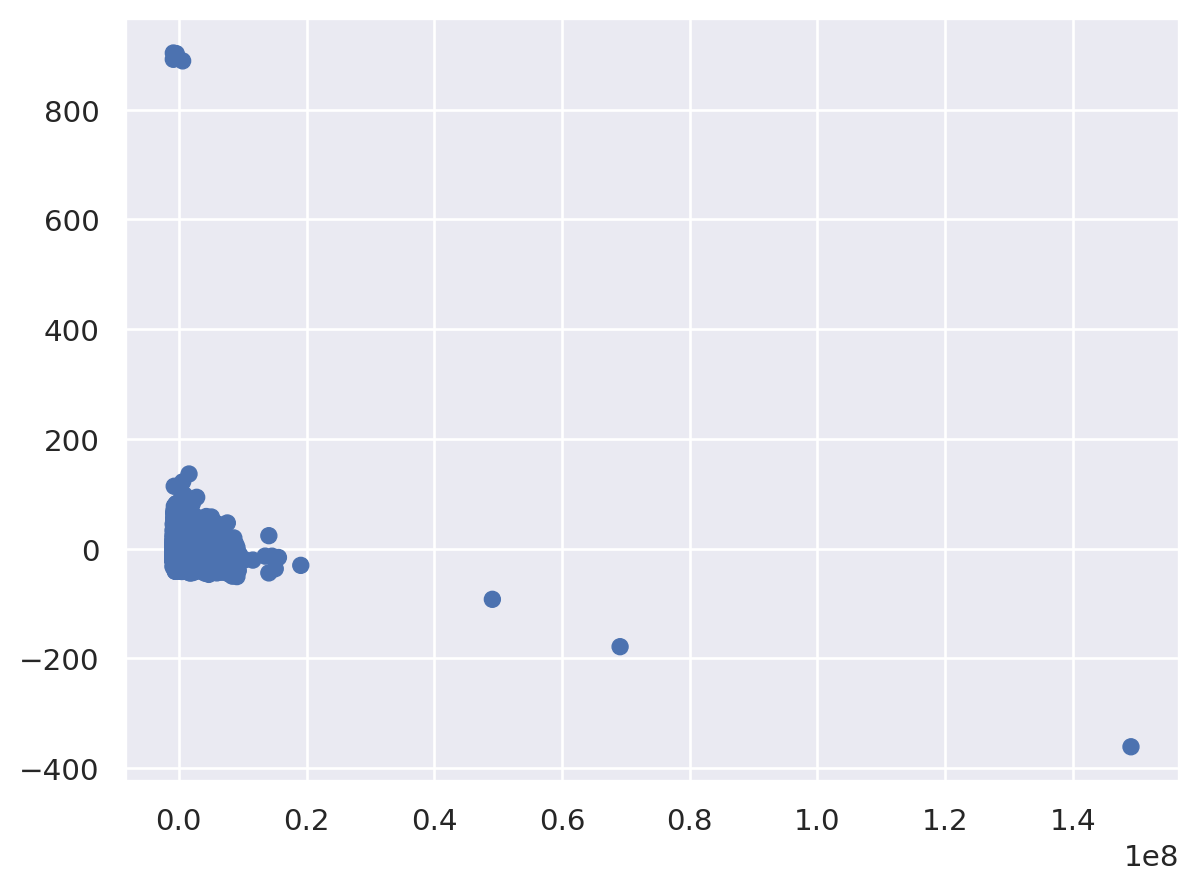

In [ ]:
(
    so.Plot(x=Z1,y=Z2)
    .add(so.Dot())
)

Se puede observar que la gran mayoría de los puntos estan en una especie de cluster, pero esto no nos aporta mucha información, por lo tanto vemos como nos queda si esclamos los datos.

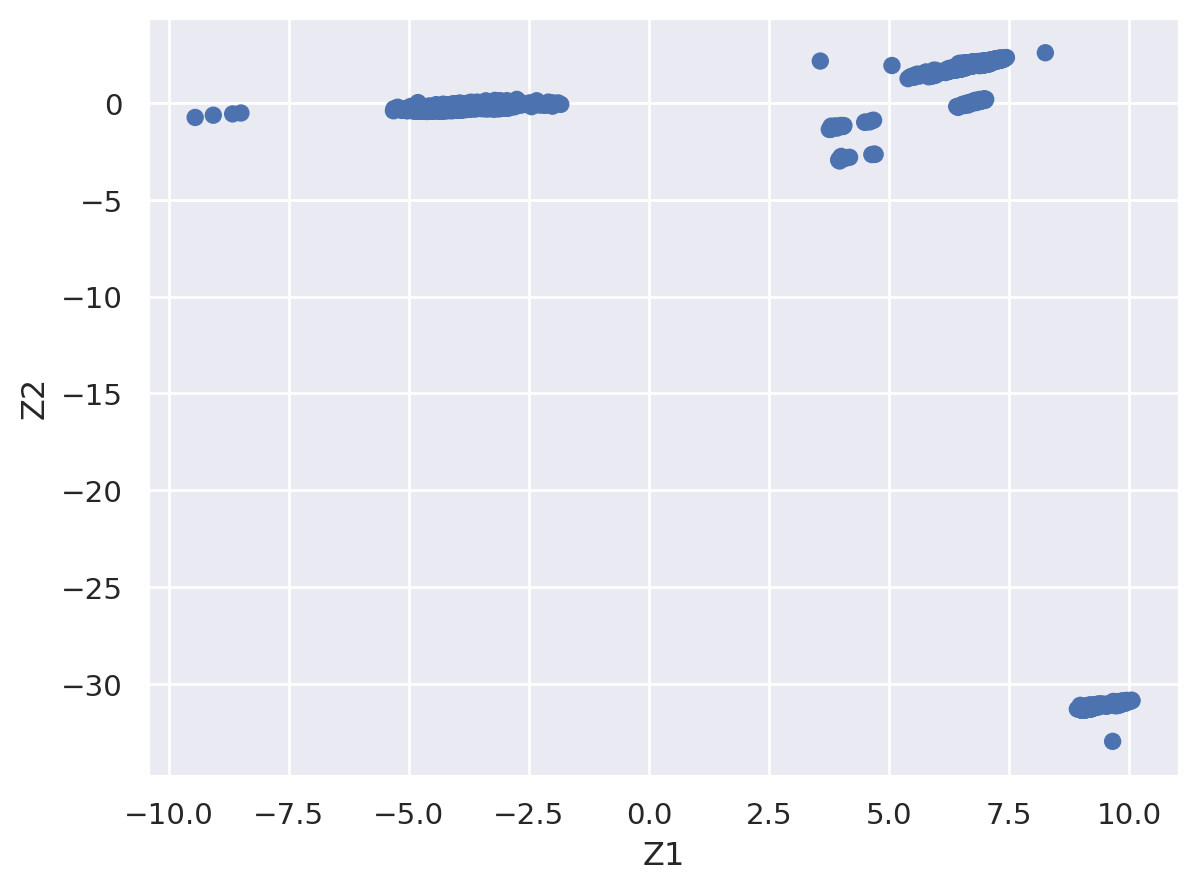

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering) #Escalamos

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(Z, columns=['Z1', 'Z2']) # renombramos para graficar

so.Plot(df_pca, x='Z1', y='Z2').add(so.Dot()) # gráfico ejercicio 10

Observamos outliers en el gráfico. DBSCAN es preferible a K-Means porque identifica outliers como ruido en lugar de forzarlos dentro de un cluster.

## Ejercicio 11

In [ ]:
for eps in [0.1,0.5,1,2,4,6]: #usamos más pero por limitaciones del colab probamos con estos por ahora, lo probamos con otros valores también
    db = DBSCAN(eps=eps, min_samples=5)
    etiquetas = db.fit_predict(X_scaled)
    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_outliers = list(etiquetas).count(-1)
    print(f"eps={eps} → clusters={n_clusters}, outliers={n_outliers}")

eps=0.1 → clusters=42, outliers=21626
eps=0.5 → clusters=320, outliers=18392
eps=1 → clusters=278, outliers=14101
eps=2 → clusters=558, outliers=9246
eps=4 → clusters=160, outliers=3624
eps=6 → clusters=135, outliers=1238


Algunos resultados que obtuvimos para distintos eps fueron:

eps=0.1 → clusters=206, outliers=21004

eps=0.5 → clusters=660, outliers=17085

eps=1 → clusters=664, outliers=12430

eps=2 → clusters=1023, outliers=7523

eps=4 → clusters=288, outliers=2922

eps=6 → clusters=204, outliers=899

eps=8 → clusters=107, outliers=376

eps=10 → clusters=68, outliers=140

eps=15 → clusters=56, outliers=63

eps=20 → clusters=26, outliers=23

También fueron probados distintos valores de min_samples, pero de igual manera se obtuvieron numeros de clusters muy altos.

Incluso en los mejores casos tenemos cientos de clusters y miles de outliers. Eso indica que los datos en el espacio original (todas las columnas) no tienen la estructura de densidad uniforme que DBSCAN necesita.

El problema probable es que df_clustering tiene muchas columnas (especialmente después de pasar SECTOR a dummies), y en espacios de alta dimensionalidad las distancias euclidianas pierden significado, todos los puntos quedan "igual de lejos" entre sí. Esto se llama la maldición de la dimensionalidad.

Probamos cambiando a K-Means y usando el método del codo:

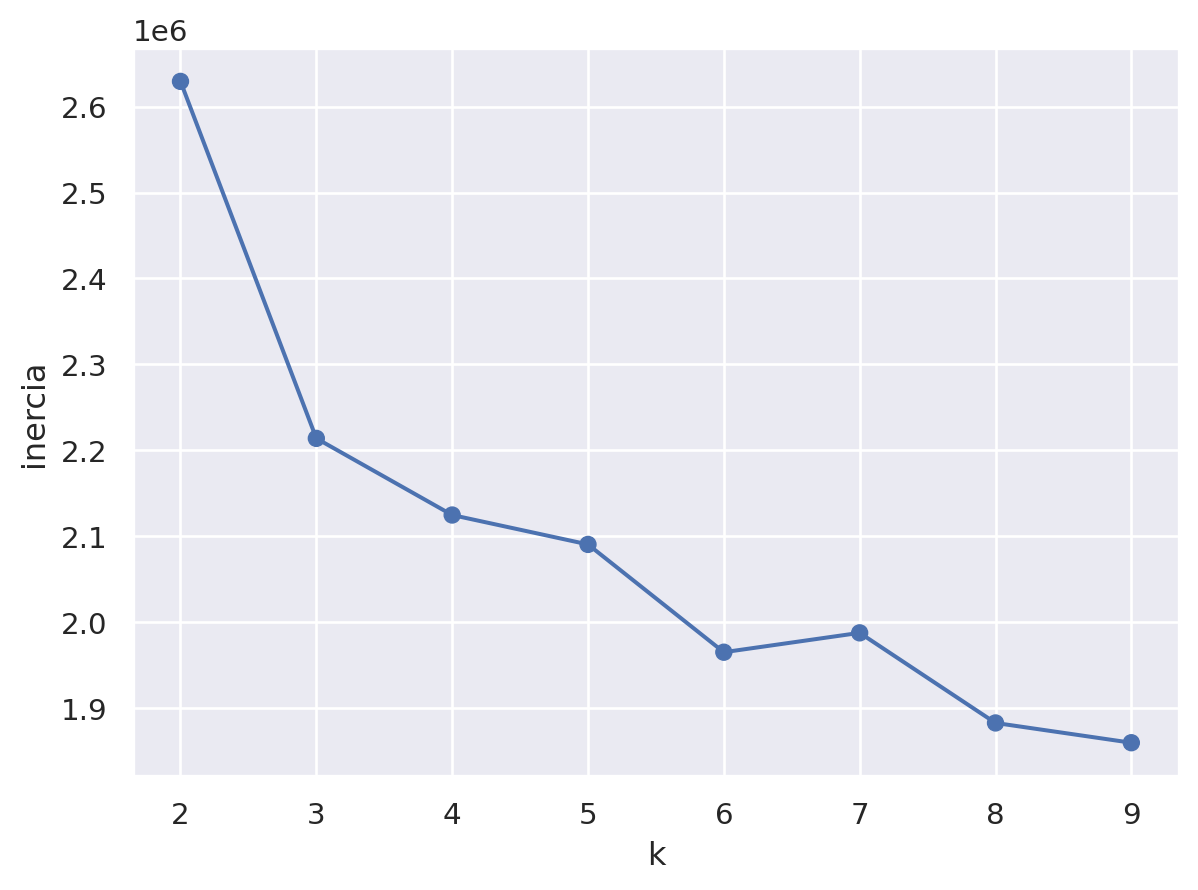

In [ ]:
inercias = []
ks = range(2, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(X_scaled)
    inercias.append(km.inertia_)

so.Plot(
    pd.DataFrame({'k': list(ks), 'inercia': inercias}),
    x='k', y='inercia'
).add(so.Line()).add(so.Dot())

El método del codo sugiere K=3, donde se observa la mayor reducción de inercia antes de que la curva se aplane.

In [ ]:
km = KMeans(n_clusters=3, random_state=0, n_init="auto")
etiquetas = km.fit_predict(X_scaled)

## Ejercicio 12

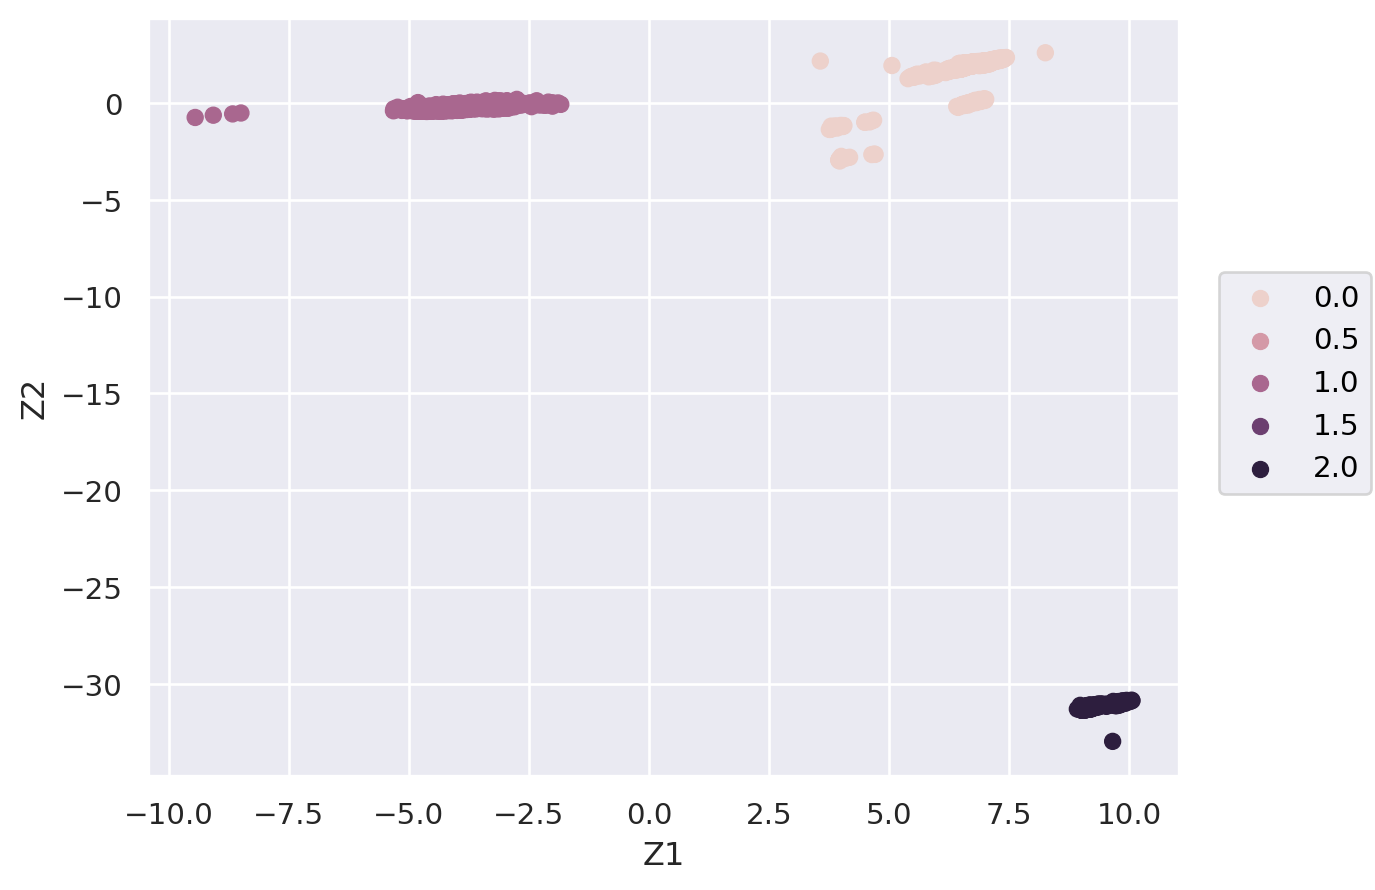

In [ ]:
so.Plot(df_pca, x='Z1', y='Z2', color = etiquetas).add(so.Dot())

Graficamos convirtiendo etiquetas a string para tener colores mas diferenciados:

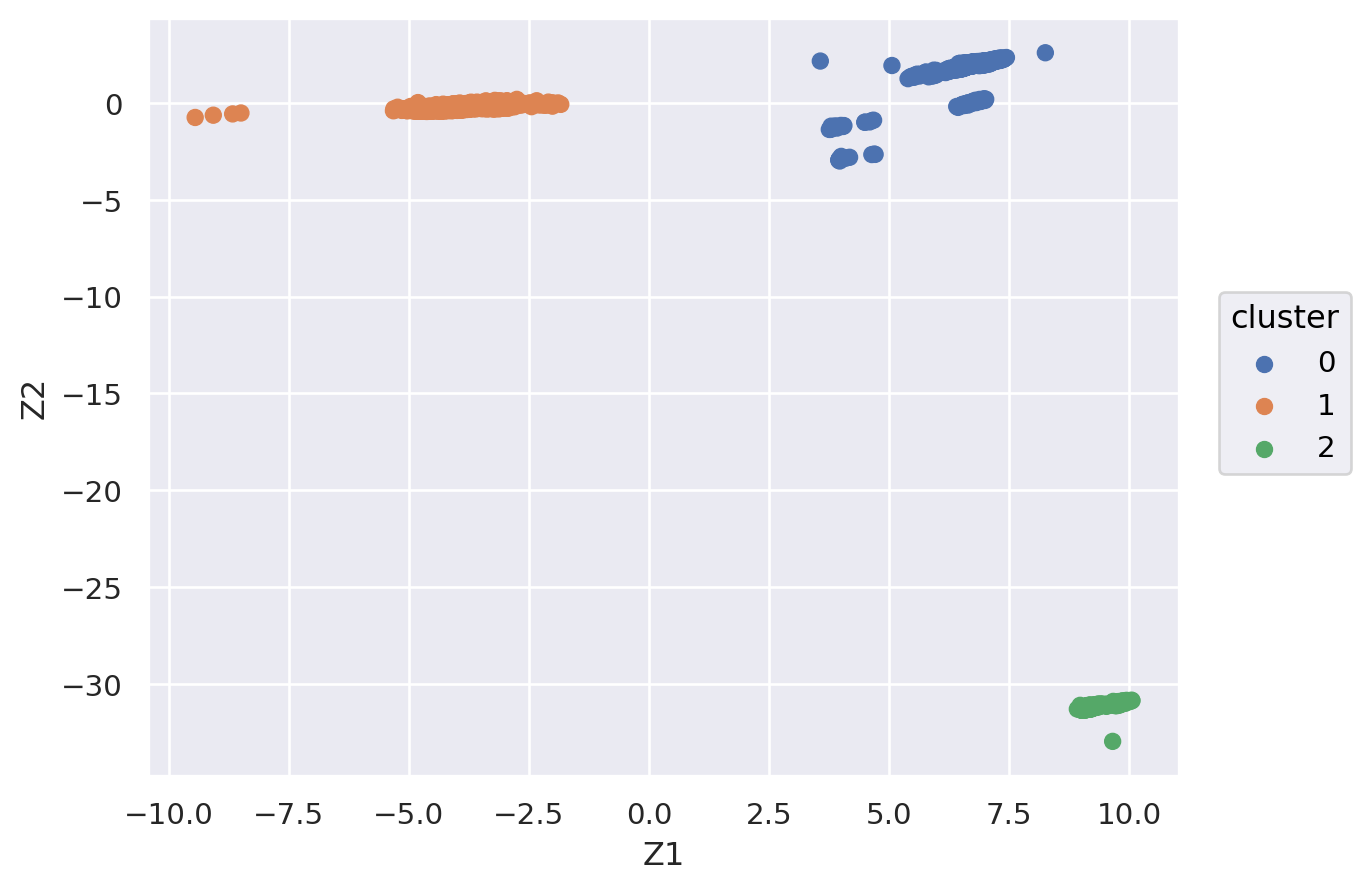

In [ ]:
df_pca['cluster'] = etiquetas.astype(str)  # convertir a string
so.Plot(df_pca, x='Z1', y='Z2', color='cluster').add(so.Dot())

Probamos con K=4 para ver si gráficamente hay una mejora:

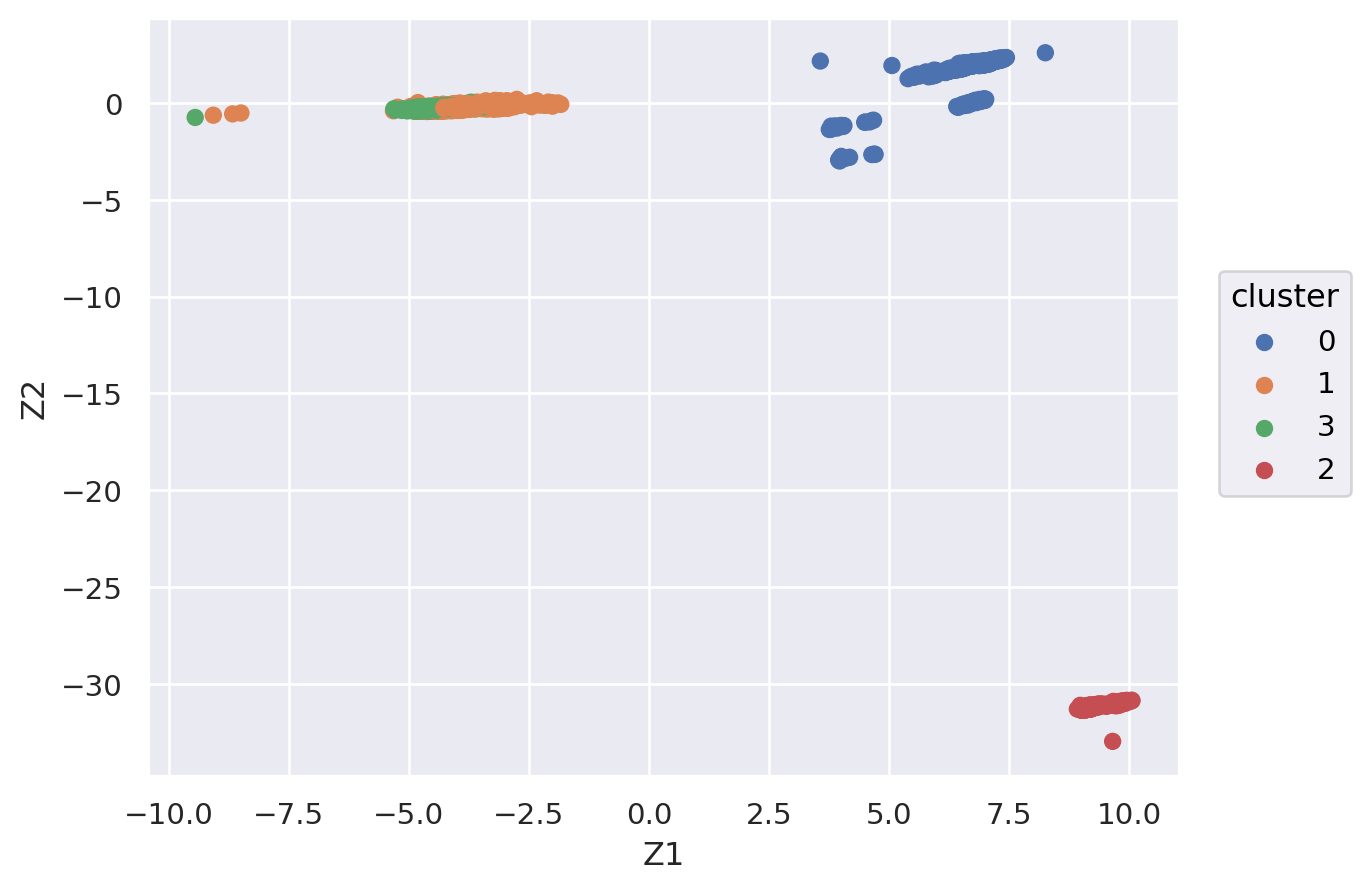

In [ ]:
km = KMeans(n_clusters=4, random_state=0, n_init="auto")
etiquetas = km.fit_predict(X_scaled)
df_pca['cluster'] = etiquetas.astype(str)  # convertir a string
so.Plot(df_pca, x='Z1', y='Z2', color='cluster').add(so.Dot())

Al hacer k-means con 4 clusters, los dos de la izquierda se mezclan, por lo que no se distinguen agrupaciones claras. Por lo tanto concluimos que lo mejor será tomar al modelo de k-means con 3 clusters como la mejor opción.

Repasamos como queda de esta forma:

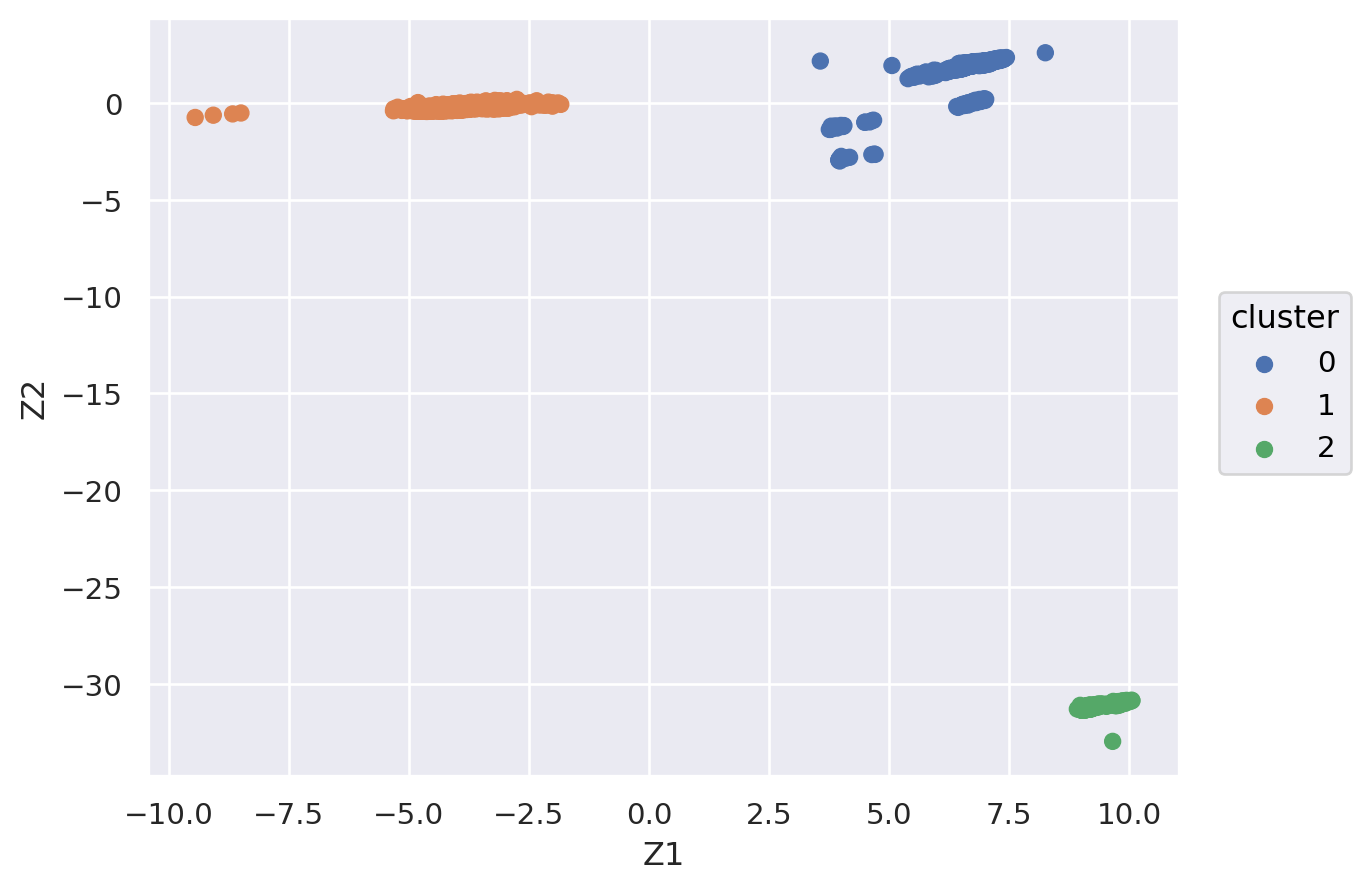

In [ ]:
km = KMeans(n_clusters=3, random_state=0, n_init="auto")
etiquetas = km.fit_predict(X_scaled)
df_pca['cluster'] = etiquetas.astype(str)  # convertir a string
so.Plot(df_pca, x='Z1', y='Z2', color='cluster').add(so.Dot())

## Ejercicio 13

Analizamos las características de cada cluster:

In [ ]:
# Vemos promedios por cluster:

df_clustering['cluster'] = etiquetas
df_clustering.groupby('cluster').mean().T.round(2)

cluster,0,1,2
EMPLEO,0.00,1.46,0.00
CH04,1.66,1.47,1.59
CH03,1.99,1.95,2.11
CH06,60.19,41.59,37.09
CH07,3.10,2.89,3.34
...,...,...,...
SECTOR_0.0,1.00,0.00,1.00
SECTOR_1.0,0.00,0.64,0.00
SECTOR_2.0,0.00,0.25,0.00
SECTOR_3.0,0.00,0.08,0.00


Buscamos las variables más útiles para caracterizar los clusters:

In [ ]:
medias = df_clustering.groupby('cluster').mean().T.round(2)

# Diferencia entre el máximo y mínimo de cada fila
medias['diferencia'] = (medias.max(axis=1) - medias.min(axis=1)).round(2)

# Vemos las 20 variables más distintas entre clusters:
medias.sort_values('diferencia', ascending=False).head(20)

cluster,0,1,2,diferencia
P47T,634164.11,1055248.56,461352.39,593896.17
PP3E_TOT,0.00,35.51,0.00,35.51
CH06,60.19,41.59,37.09,23.10
PP04C,0.00,5.05,0.00,5.05
PP04B1,0.00,1.92,0.00,1.92
PP3F_TOT,0.00,1.48,0.00,1.48
EMPLEO,0.00,1.46,0.00,1.46
ESTADO_2,0.00,0.00,1.00,1.00
ESTADO_1,0.00,1.00,0.00,1.00
ESTADO_3,1.00,0.00,0.00,1.00


In [ ]:
medias.sort_values('diferencia', ascending=False).where(medias['diferencia']>1).dropna()

cluster,0,1,2,diferencia
P47T,634164.11,1055248.56,461352.39,593896.17
PP3E_TOT,0.00,35.51,0.00,35.51
CH06,60.19,41.59,37.09,23.10
PP04C,0.00,5.05,0.00,5.05
PP04B1,0.00,1.92,0.00,1.92
PP3F_TOT,0.00,1.48,0.00,1.48
EMPLEO,0.00,1.46,0.00,1.46


Buscamos en la documentación a qué hacen referencia estas variables para completar el análisis:

* P47T → Monto de ingreso total individual (sumatoria ingresos laborales y no
laborales)
* PP3E_TOT → Total de horas que trabajó en la semana en la ocupación principal
* CH06 → ¿Cuántos años cumplidos tiene?
* PP04C → ¿Cuántas personas trabajan allí en total? (Personas que trabajan en la misma empresa, institución, etc.)
* PP3F_TOT → Total de horas que trabajó en la semana en otras ocupaciones
* PP04B1 → Si presta servicio doméstico en hogares particulares 1 = casa de familia
* EMPLEO → Tipo de empleo: 1 = Formal 2 = Informal 9 = Ns/Nr

La variable PP3E_TOTAL nos dice la cantidad de horas trabajadas, de allí el cluster 1 es el de la población de trabajadores activos. Esto también tiene sentido si vemos la edad promedio determinada según CH06 en 41,59 años. Este Cluster es el de ingresos mayores.

Por lo tanto los otros dos clusters corresponden a poblacion inactiva que se distingue según el grupo etáreo en jubilados o inactivos (Cluster 0) y población joven desocupada o inactiva (Cluster 2)




A partir del análisis de las variables más discriminantes entre clusters,
pudimos identificar las siguientes características:

**Cluster 1 — Trabajadores activos**: Este cluster agrupa a individuos con
empleo activo, evidenciado por un promedio de 35,51 horas semanales trabajadas
en la ocupación principal (PP3E_TOT) y 1,48 horas en ocupaciones secundarias
(PP3F_TOT). Con una edad promedio de 41,59 años y el mayor ingreso individual
(P47T = 1.055.248), se trata del grupo con mayor inserción laboral formal,
empleados en empresas de tamaño mediano (PP04C = 5,05).

**Cluster 0 — Inactivos mayores / Jubilados**: Individuos sin empleo activo
(PP3E_TOT = 0) con la edad promedio más alta (60,19 años). Sus ingresos
(P47T = 634.164), aunque bajos en comparación con el Cluster 1, sugieren
la existencia de ingresos no laborales como jubilaciones o pensiones.

**Cluster 2 — Jóvenes inactivos o desocupados**: Similar al Cluster 0 en
cuanto a ausencia de actividad laboral, pero con una edad promedio menor
(37,09 años) y los ingresos más bajos de los tres grupos (P47T = 461.352),
lo que sugiere desocupación o inactividad sin ingresos de reemplazo.

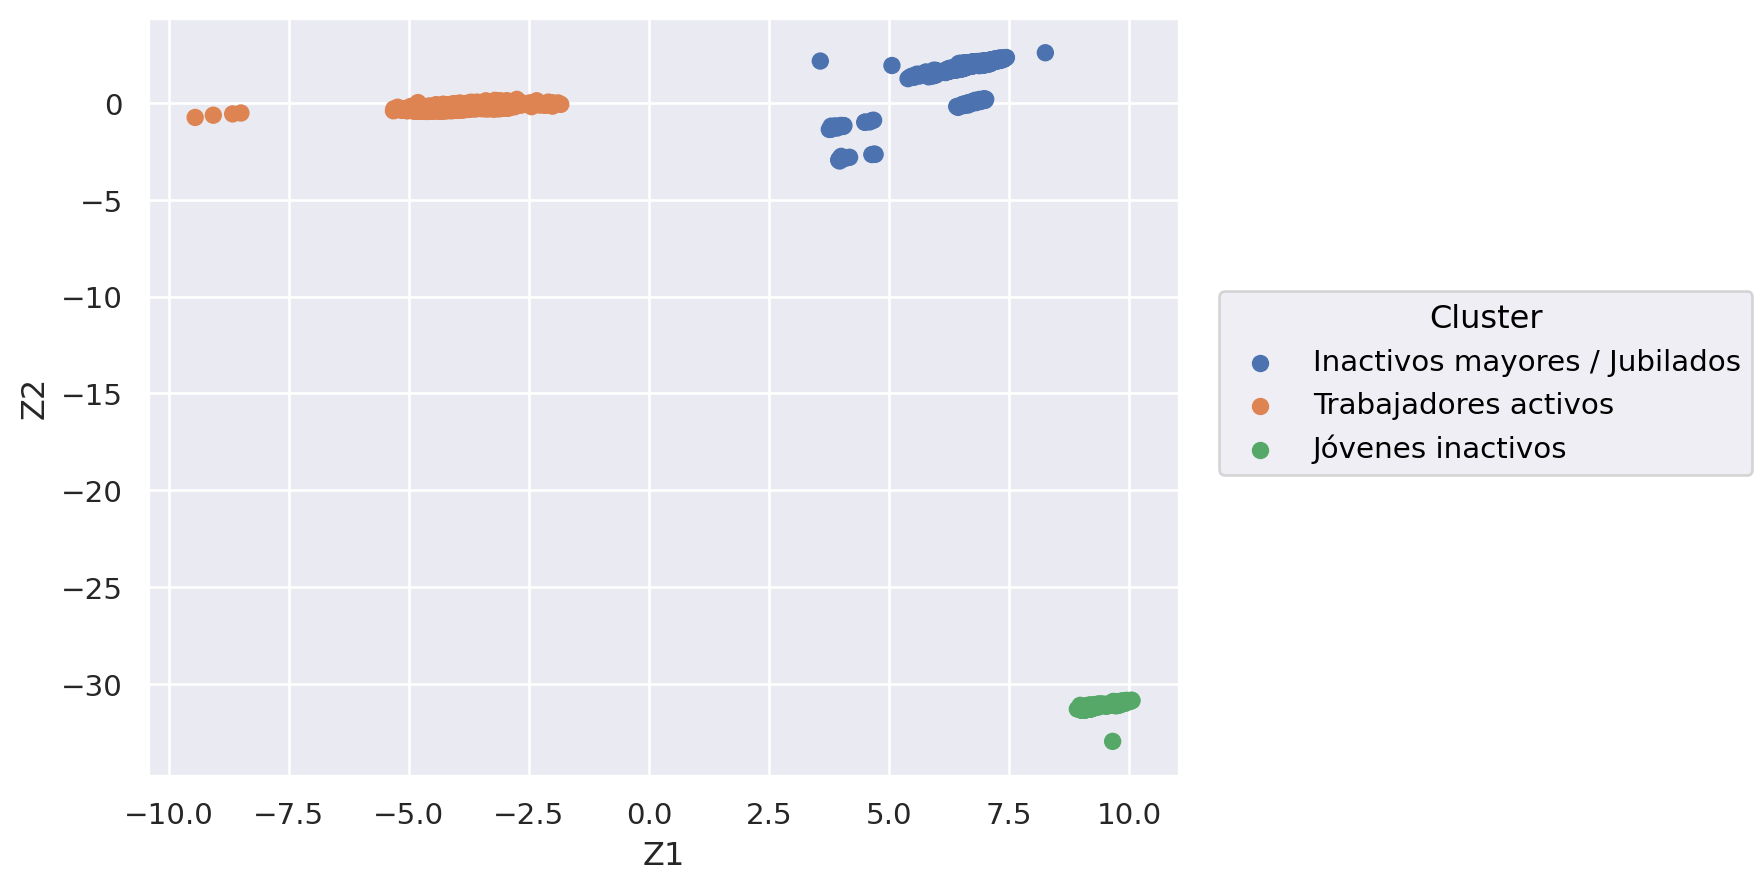

In [ ]:
# Mapear etiquetas numéricas a nombres descriptivos
nombres = {
    '0': 'Inactivos mayores / Jubilados',
    '1': 'Trabajadores activos',
    '2': 'Jóvenes inactivos'
}
df_pca['Cluster'] = df_pca['cluster'].map(nombres)

so.Plot(df_pca, x='Z1', y='Z2', color='Cluster').add(so.Dot())

Quisieramos aportar algo más de información que caracterice a los grupos descritos en los clusters, veamos si la variable nivel educativo nos dice algo:

In [ ]:
nombres = {
    '0' : 'Inactivos mayores / Jubilados',
    '1': 'Trabajadores activos',
    '2': 'Jóvenes inactivos'
}
df_clustering['Población Cluster'] = df_clustering['cluster'].astype(str).map(nombres)
df_clustering[['NIVEL_ED','Población Cluster']].groupby('Población Cluster').mean().T.round(2)

Población Cluster,Inactivos mayores / Jubilados,Jóvenes inactivos,Trabajadores activos
NIVEL_ED,3.26,3.7,4.13


* NIVEL_ED → Nivel educativo: 1 = Primario incompleto (incluye educación especial) 2 = Primario completo 3 = Secundario incompleto 4 = Secundario completo 5 = Superior y universitario incompleto 6 = Superior y universitario completo 7 = Sin instrucción 9 = Ns/Nr

El nivel educativo promedio refleja una tendencia esperable: los trabajadores
activos tienen mayor nivel de instrucción (4.13 ≈ Secundario completo) que
los jubilados (3.26 ≈ Secundario incompleto), lo que podría explicarse por
la expansión de la obligatoriedad educativa a lo largo del tiempo.
Curiosamente, los jóvenes inactivos se ubican en un valor intermedio (3.70),
sugiriendo que muchos podrían estar aún cursando estudios.

Este análisis abre varias preguntas interesantes: ¿cómo se distribuyen
geográficamente estos grupos?, ¿qué características tienen los trabajos
del cluster activo en términos de salario y sector?, ¿hace cuánto tiempo
llevan buscando empleo los jóvenes inactivos? Responder estas preguntas
permitiría caracterizar aún mejor cada grupo y orientar posibles políticas.

# Clasificación

## Ejercicio 14

Solo nos quedamos con las filas que tengan 1,2 o 3 en la variable "SECTOR".

In [ ]:
df_clean["SECTOR"].value_counts()

,count
SECTOR,
1.0,8925
0.0,8132
2.0,3448
3.0,1144
9.0,339


In [ ]:
df_clasificacion = df_clean[df_clean["SECTOR"].isin([1,2,3])].copy()

In [ ]:
df_clasificacion["SECTOR"].value_counts()

,count
SECTOR,
1.0,8925
2.0,3448
3.0,1144


## Ejercicio 15

In [ ]:
df_clasificacion["P47T"].min()

10000.0

Ya habíamos eliminado los datos que tuvieran menos de 0 en esta variable, asi que todos los valores son positivos.

In [ ]:
df_clasificacion["P47T"].head()

,P47T
1,400000.0
2,1200000.0
5,500000.0
6,930000.0
7,3000000.0


In [ ]:
df_clasificacion["P47T"] = np.log(df_clasificacion["P47T"])


In [ ]:
df_clasificacion["P47T"].head()

,P47T
1,12.899220
2,13.997832
5,13.122363
6,13.742940
7,14.914123


## Ejercicio 16

Normalizamos df_clasificacion, otra vez usando StandardScaler, para que sea más robusto frente a valores atípicos (como es una columna de ingreso tiene mucho sentido que hayan):

In [ ]:
df_clasificacion.head()

,EMPLEO,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,SECTOR,PP3E_TOT,...,PP04G_6.0,PP04G_7.0,PP04G_8.0,PP04G_9.0,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0,SOLTERX,SABE_LEER
1,2.0,1,2,39,1,1,2,4,2.0,36.0,...,0,0,1,0,0,0,0,0,0,1
2,1.0,1,1,50,2,1,2,3,1.0,35.0,...,0,0,0,0,0,1,0,0,0,1
5,1.0,1,5,29,5,1,2,4,1.0,20.0,...,0,0,0,0,0,1,0,0,1,1
6,1.0,1,1,32,3,1,2,4,1.0,30.0,...,0,0,0,1,0,0,0,0,0,1
7,1.0,2,1,29,1,1,2,5,1.0,40.0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
df_clasificacion_aux = df_clasificacion.copy() #creamos una copia del df para usar en el ej 17, ya que tambien hay que normalizar pero de otra forma

scaler = StandardScaler().set_output(transform="pandas")
df_clasificacion_escalado = scaler.fit_transform(df_clasificacion.drop(columns="SECTOR"))

Hacemos PCA:

In [ ]:
pca = PCA(n_components=2)
Z = pca.fit_transform(df_clasificacion_escalado)
Z1=Z[:,0]
Z2=Z[:,1]

In [ ]:
df_clasificacion_escalado["Z1"]=Z1
df_clasificacion_escalado["Z2"]=Z2

Graficamos Z1 vs Z2

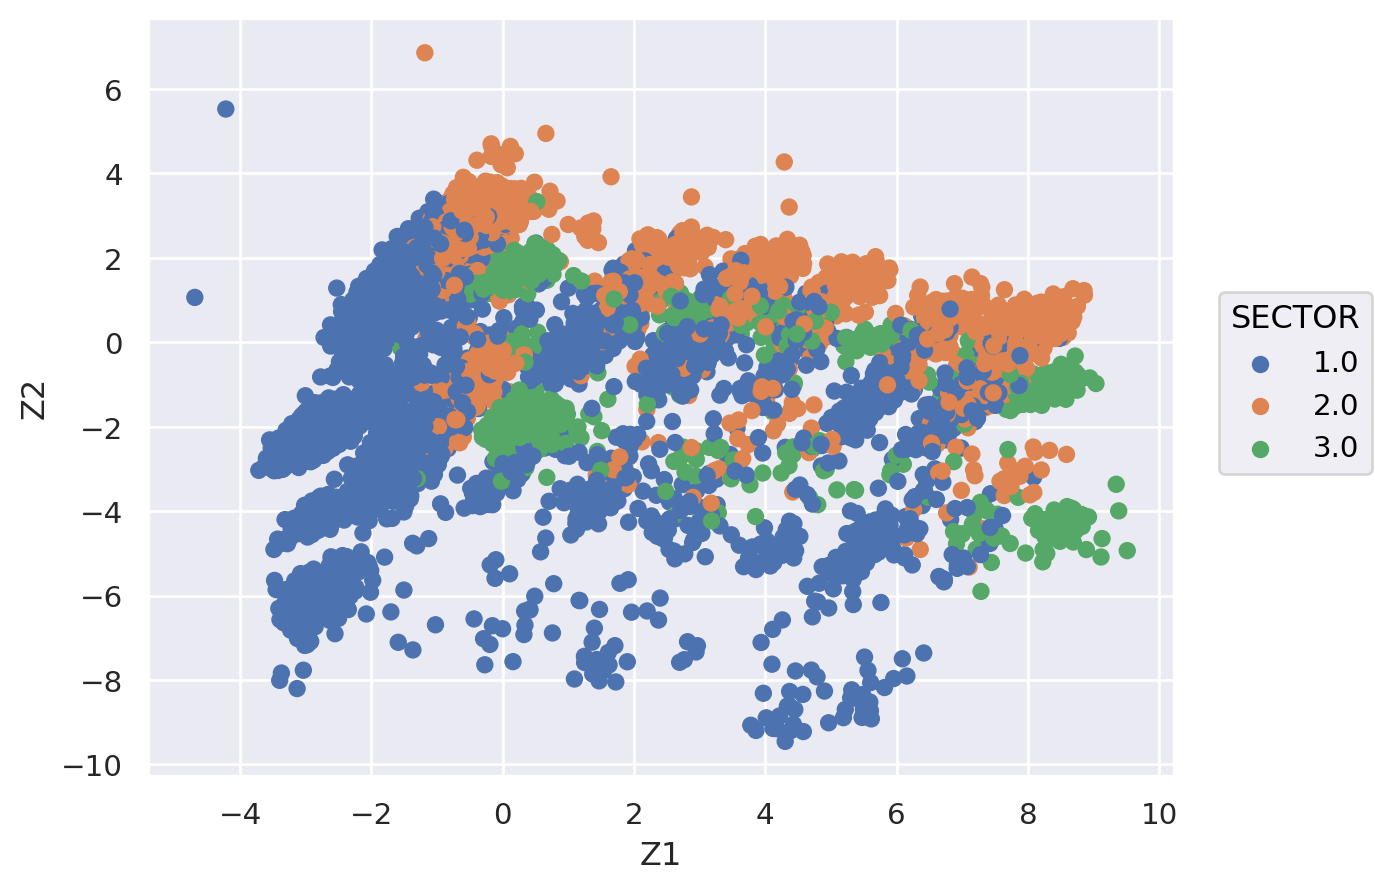

In [ ]:
(
    so.Plot(data=df_clasificacion_escalado,x="Z1",y="Z2",color=df_clasificacion_aux["SECTOR"])
    .scale(color="deep") #color="deep" usa los colores clásicos
    .add(so.Dot())
)

Podemos observar una cierta tendencia: Los puntos pertenecientes a un mismo sector se superponen un poco con los de otros, pero si se distingue de forma clara cada sector porque hay subagrupamientos dento de cada uno.

Lo mas probable es que esto se deba a que en cada una de estas nubes, los integrantes tengan características en comun.

## Ejercicio 17

### Item a

Separamos el conjunto de datos escalados en entrenamiento y prueba:

In [ ]:
#vamos a usar df_clasificacion_aux
df_train, df_test = train_test_split(df_clasificacion_aux, test_size=0.2, random_state=42)

### Item b

Escalamos solo el df de entrenamiento:

In [ ]:
scaler = StandardScaler()

y_train, X_train = model_matrix('SECTOR ~ . - 1',df_train)
y_test, X_test = model_matrix('SECTOR ~ . - 1',df_test)

y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #ajustamos con los datos de entrenamiento y entrenamos con los de testeo, para no sobreescribir el ajuste

### Item c

Hacemos KNN con distintos valores de K, y nos quedamos con el que más acierte:

In [ ]:
cv = KFold(n_splits=5, random_state=42, shuffle=True)

for K in range(1,20,2):

    acc_score = np.zeros(cv.get_n_splits())
    neighbor = KNeighborsClassifier(n_neighbors=K)

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        neighbor.fit(X_t, y_t)

        y_pred = neighbor.predict(X_v)
        acc_score[ind] = accuracy_score(y_v, y_pred)

        ind += 1

    print(f"K={K} → Accuracy: {acc_score.mean():.4f}")

K=1 → Accuracy: 0.8907
K=3 → Accuracy: 0.8960
K=5 → Accuracy: 0.8985
K=7 → Accuracy: 0.8998
K=9 → Accuracy: 0.8986
K=11 → Accuracy: 0.9003
K=13 → Accuracy: 0.8975
K=15 → Accuracy: 0.8963
K=17 → Accuracy: 0.8967
K=19 → Accuracy: 0.8970


Se puede ver, levemente, que K=11 es el valor que mejor se desempeña al hacer KNN, por lo tanto para predecir el sector de un nuevo vecino, hay que ver lo que vale sector para los 11 más cercanos a este.

### Item d

Vemos como se desempeña usando los datos de prueba:

In [ ]:
neighbor = KNeighborsClassifier(n_neighbors=11)
neighbor.fit(X_train_scaled, y_train)
y_pred = neighbor.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))

0.915680473372781


La precisión del método es de un 91,56%.

### Item e

Creemos que las variables que son valiosas para predecir el sector (Si es formal, informal u hogares) son:

- PP04C: Cantidad de personas que trabajan en ese establecimiento.

- PP04G: Donde realiza sus tareas.

- P47T: Ingresos.

Hacemos un modelo, también con K=11, para ver como se vió afectada la precisión:

In [ ]:
cols_no_valiosas = [col for col in df_clasificacion_aux.columns if not col.startswith(("PP04C","PP04G","P47T"))]
df_clasificacion_aux_no_valiosas = df_clasificacion_aux[cols_no_valiosas]

df_train, df_test = train_test_split(df_clasificacion_aux_no_valiosas, test_size=0.2, random_state=42)

scaler = StandardScaler()

y_train, X_train = model_matrix('SECTOR ~ . - 1',df_train)
y_test, X_test = model_matrix('SECTOR ~ . - 1',df_test)

y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #ajustamos con los datos de entrenamiento y entrenamos con los de testeo, para no sobreescribir el ajuste

neighbor = KNeighborsClassifier(n_neighbors=11)
neighbor.fit(X_train_scaled, y_train)
y_pred = neighbor.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))

0.911612426035503


Probamos con otras variables, para ver si empeora un poco más, ya que actualmente la precisión disminuyó de 91,56% a 91,16%, no es una variación significativa.

- NIVEL_ED

- CH0G (Edad)

- P47T

In [ ]:
cols_no_valiosas = [col for col in df_clasificacion_aux.columns if not col.startswith(("NIVEL_ED","CH0G","P47T"))]
df_clasificacion_aux_no_valiosas = df_clasificacion_aux[cols_no_valiosas]

df_train, df_test = train_test_split(df_clasificacion_aux_no_valiosas, test_size=0.2, random_state=42)

scaler = StandardScaler()

y_train, X_train = model_matrix('SECTOR ~ . - 1',df_train)
y_test, X_test = model_matrix('SECTOR ~ . - 1',df_test)

y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #ajustamos con los datos de entrenamiento y entrenamos con los de testeo, para no sobreescribir el ajuste

neighbor = KNeighborsClassifier(n_neighbors=11)
neighbor.fit(X_train_scaled, y_train)
y_pred = neighbor.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))

0.9112426035502958


Al cambiar dos de las variables, obtuvimos una precisión de 91,12%, casi igual al modelo anterior.

En conclusión, según las variables estudiadas en este último item, tres variables valiosas para predecir el sector de un trabajo son la edad, ingreso y nivel educativo (las tres en conjunto).

Sin embargo, el modelo apenas empeoró al no considerarlas, por lo que no son tan significativas.

Se podrían probar muchos modelos tomando distintas variables, pero las que fueron seleccionadas son las que a priori tiene más sentido que sean valiosas para predecir el sector.

Por lo tanto, se puede suponer que el sector depende de muchas variables en conjunto, y no tanto de unas pocas.

# Regresión

## Ejercicio 18

El df ya tiene filtradas las personas que tienen un ingreso positivo:

In [ ]:
df_clean["P47T"].min()

220.0

In [ ]:
df_regresion = df_clean.copy()

## Ejercicio 19

In [ ]:
df_regresion["P47T"]

,P47T
0,552000.0
1,400000.0
2,1200000.0
3,1000000.0
4,1200000.0
...,...
21983,378000.0
21984,490000.0
21985,1370000.0
21986,700000.0


In [ ]:
df_regresion["P47T"] = np.log(df_regresion["P47T"])

In [ ]:
df_regresion["P47T"]

,P47T
0,13.221303
1,12.899220
2,13.997832
3,13.815511
4,13.997832
...,...
21983,12.842649
21984,13.102161
21985,14.130321
21986,13.458836


## Ejerrcicio 20

In [ ]:
df_train, df_test = train_test_split(df_regresion, test_size=0.2, random_state=42)

y_train, X_train = model_matrix('P47T ~ . - 1',df_train)
y_test, X_test = model_matrix('P47T ~ . - 1',df_test)

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #ajustamos con los datos de entrenamiento y entrenamos con los de testeo, para no sobreescribir el ajuste

cv = KFold(n_splits=5, random_state=42, shuffle=True)

Como X tiene muchas columnas, sospechamos que puede llegar a haber colinealidad exacta o aproximada pero muy fuerte, asi que podemos probar un modelo lineal común que considere todas las variables, y un modelo lineal Ridge que considere las mismas, para ver si esto efectivamente es así.x

### Modelo 1: multivariado lineal

In [ ]:
modelo1 = LinearRegression(fit_intercept = True)
rmse1 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

ind = 0

for train_index, val_index in cv.split(X_train_scaled):
    X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
    modelo1.fit(X_t, y_t)

    y_pred = modelo1.predict(X_v)
    rmse1[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
    ind = ind + 1

print(f"La raíz del error cuadrático medio es : {rmse1.mean():.7f}")

La raíz del error cuadrático medio es : 0.6316518


### Modelo 2: multivariado lineal Ridge

In [ ]:
alphas = [0.1,0.25,0.5,1,2,4,8,10,15,20,30,40,50] #usamos una amplio rango de alphas para ver cual va a ser el mas preciso para el modelo
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo2 = Ridge(alpha = alpha, fit_intercept = True)
    rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo2.fit(X_t, y_t)

        y_pred = modelo2.predict(X_v)
        rmse2[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse2.mean():.7f}")

    error_alphas[counter] = rmse2.mean()

Para alpha = 0.10 la raíz del error cuadrático medio es : 0.6316515
Para alpha = 0.25 la raíz del error cuadrático medio es : 0.6316511
Para alpha = 0.50 la raíz del error cuadrático medio es : 0.6316503
Para alpha = 1.00 la raíz del error cuadrático medio es : 0.6316489
Para alpha = 2.00 la raíz del error cuadrático medio es : 0.6316459
Para alpha = 4.00 la raíz del error cuadrático medio es : 0.6316401
Para alpha = 8.00 la raíz del error cuadrático medio es : 0.6316287
Para alpha = 10.00 la raíz del error cuadrático medio es : 0.6316230
Para alpha = 15.00 la raíz del error cuadrático medio es : 0.6316091
Para alpha = 20.00 la raíz del error cuadrático medio es : 0.6315954
Para alpha = 30.00 la raíz del error cuadrático medio es : 0.6315687
Para alpha = 40.00 la raíz del error cuadrático medio es : 0.6315430
Para alpha = 50.00 la raíz del error cuadrático medio es : 0.6315182


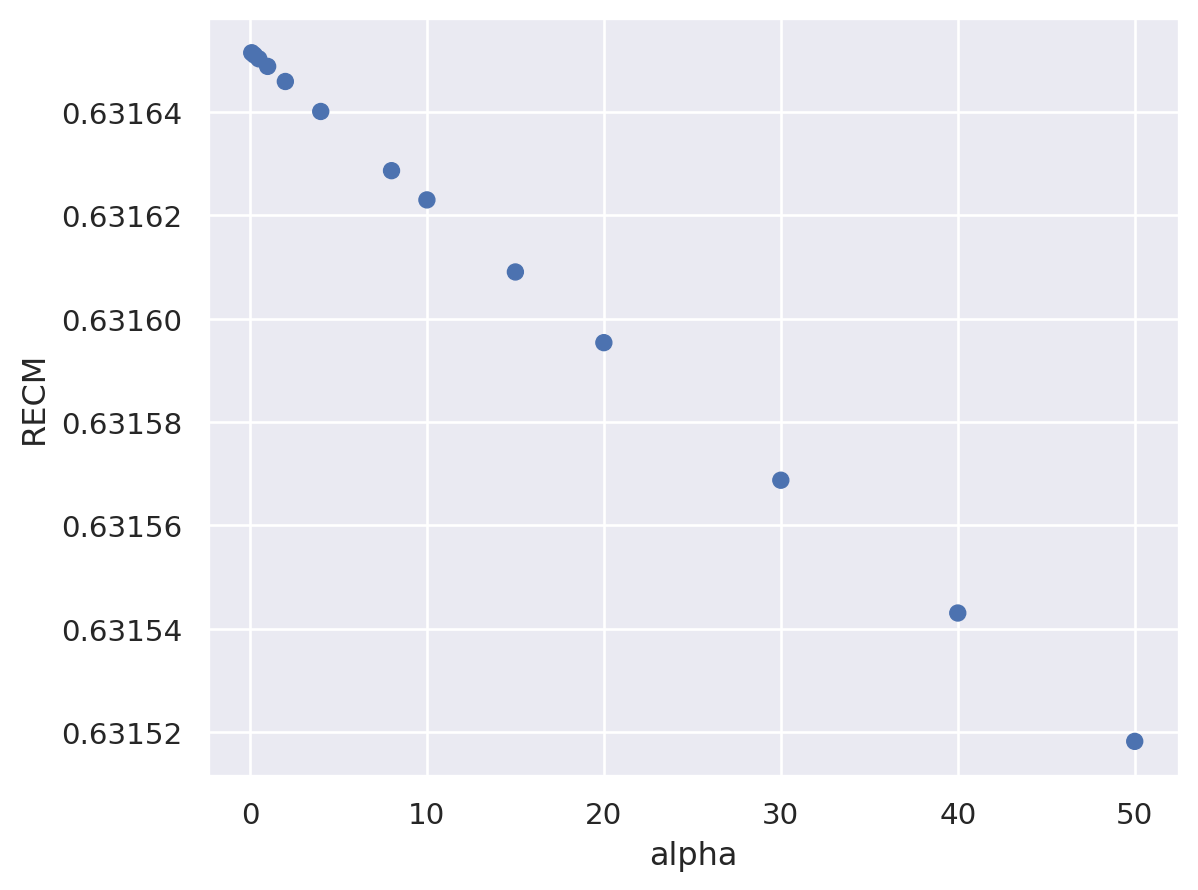

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Vemos que con alphas mas altos podría mejorar

In [ ]:
alphas = range(50,100,5)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo2 = Ridge(alpha = alpha, fit_intercept = True)
    rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo2.fit(X_t, y_t)

        y_pred = modelo2.predict(X_v)
        rmse2[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse2.mean():.7f}")

    error_alphas[counter] = rmse2.mean()

Para alpha = 50.00 la raíz del error cuadrático medio es : 0.6315182
Para alpha = 55.00 la raíz del error cuadrático medio es : 0.6315061
Para alpha = 60.00 la raíz del error cuadrático medio es : 0.6314941
Para alpha = 65.00 la raíz del error cuadrático medio es : 0.6314824
Para alpha = 70.00 la raíz del error cuadrático medio es : 0.6314709
Para alpha = 75.00 la raíz del error cuadrático medio es : 0.6314596
Para alpha = 80.00 la raíz del error cuadrático medio es : 0.6314484
Para alpha = 85.00 la raíz del error cuadrático medio es : 0.6314374
Para alpha = 90.00 la raíz del error cuadrático medio es : 0.6314267
Para alpha = 95.00 la raíz del error cuadrático medio es : 0.6314161


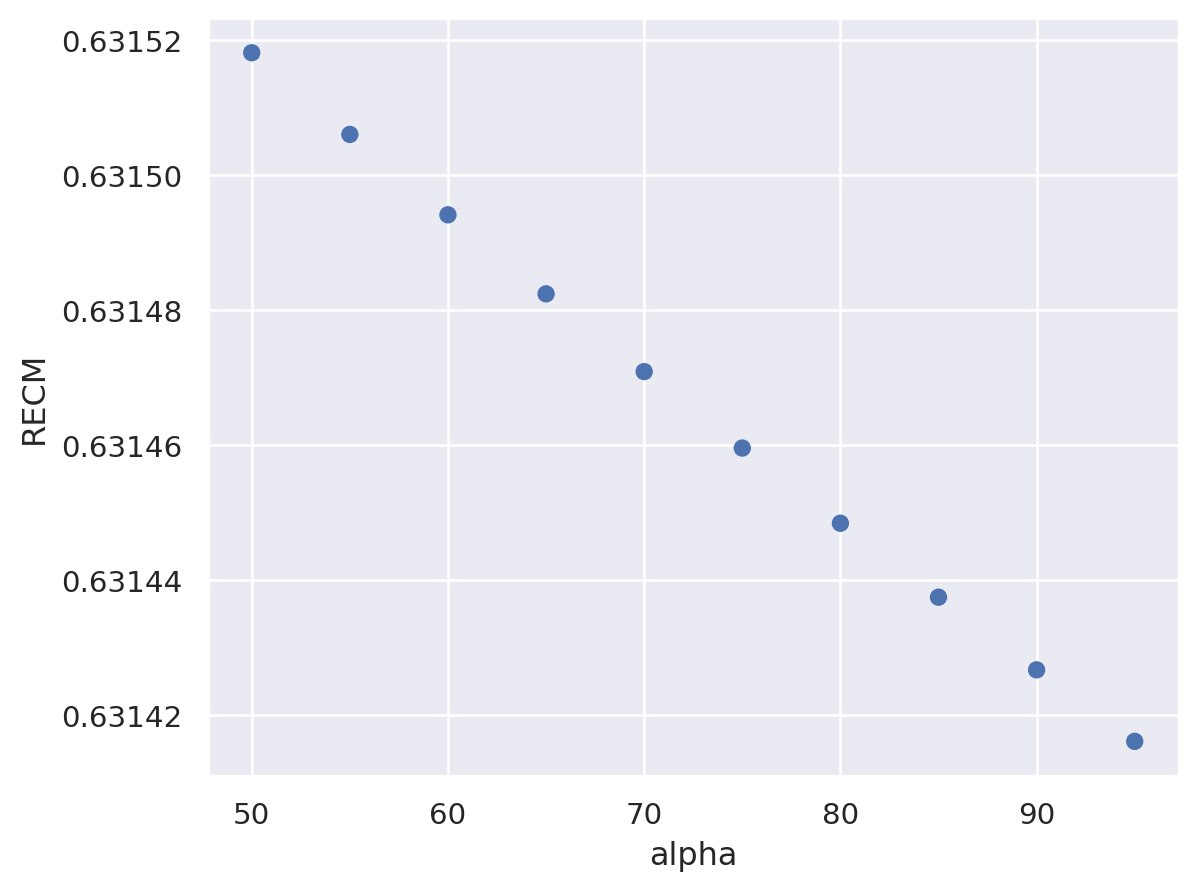

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Seguimos viendo valores de alpha mayores, porque sigue disminuyendo:

In [ ]:
alphas = range(100,300,10)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo2 = Ridge(alpha = alpha, fit_intercept = True)
    rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo2.fit(X_t, y_t)

        y_pred = modelo2.predict(X_v)
        rmse2[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse2.mean():.8f}")
    error_alphas[counter] = rmse2.mean()

Para alpha = 100.00 la raíz del error cuadrático medio es : 0.63140565
Para alpha = 110.00 la raíz del error cuadrático medio es : 0.63138533
Para alpha = 120.00 la raíz del error cuadrático medio es : 0.63136570
Para alpha = 130.00 la raíz del error cuadrático medio es : 0.63134674
Para alpha = 140.00 la raíz del error cuadrático medio es : 0.63132844
Para alpha = 150.00 la raíz del error cuadrático medio es : 0.63131080
Para alpha = 160.00 la raíz del error cuadrático medio es : 0.63129378
Para alpha = 170.00 la raíz del error cuadrático medio es : 0.63127739
Para alpha = 180.00 la raíz del error cuadrático medio es : 0.63126160
Para alpha = 190.00 la raíz del error cuadrático medio es : 0.63124642
Para alpha = 200.00 la raíz del error cuadrático medio es : 0.63123182
Para alpha = 210.00 la raíz del error cuadrático medio es : 0.63121779
Para alpha = 220.00 la raíz del error cuadrático medio es : 0.63120433
Para alpha = 230.00 la raíz del error cuadrático medio es : 0.63119143
Para a

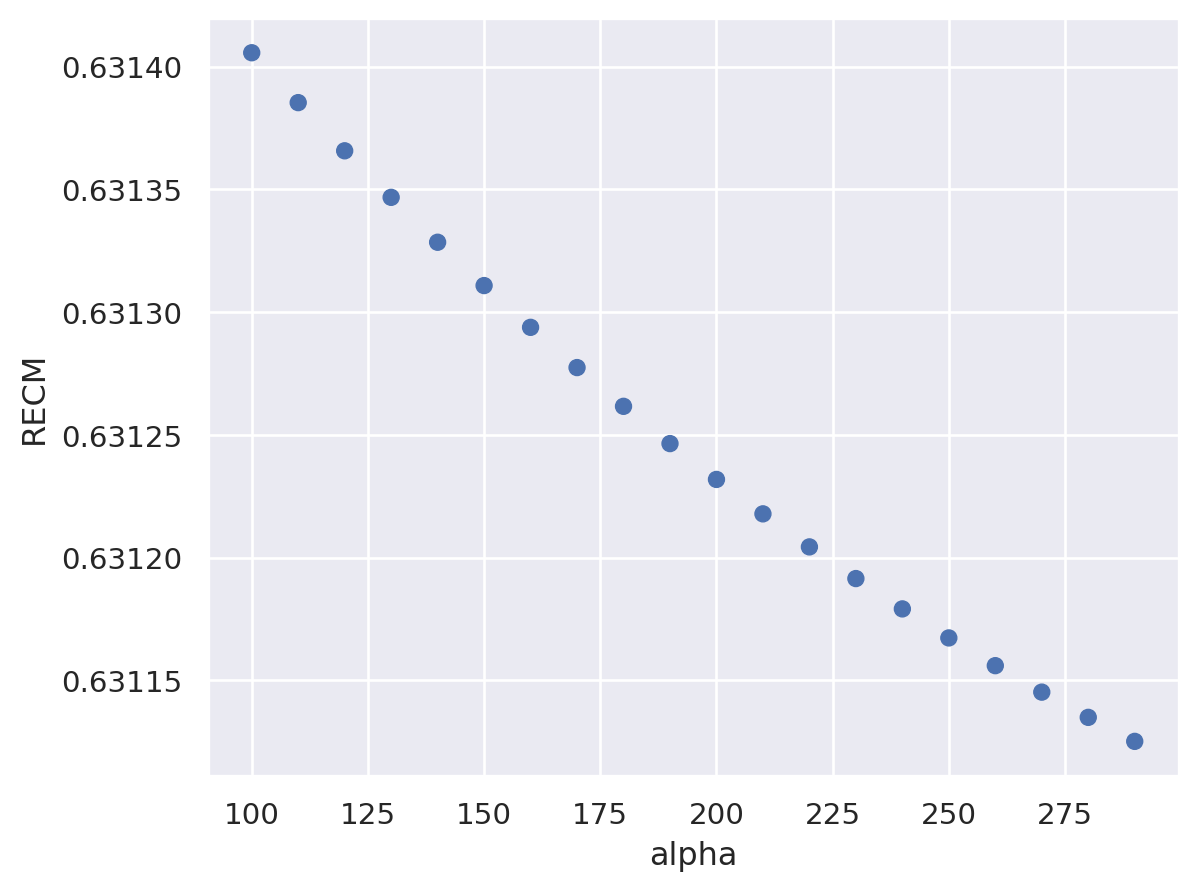

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Seguimos probando hasta encontrar un mínimo:

In [ ]:
alphas = range(300,500,10)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo2 = Ridge(alpha = alpha, fit_intercept = True)
    rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo2.fit(X_t, y_t)

        y_pred = modelo2.predict(X_v)
        rmse2[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse2.mean():.8f}")
    error_alphas[counter] = rmse2.mean()

Para alpha = 300.00 la raíz del error cuadrático medio es : 0.63111581
Para alpha = 310.00 la raíz del error cuadrático medio es : 0.63110700
Para alpha = 320.00 la raíz del error cuadrático medio es : 0.63109866
Para alpha = 330.00 la raíz del error cuadrático medio es : 0.63109078
Para alpha = 340.00 la raíz del error cuadrático medio es : 0.63108336
Para alpha = 350.00 la raíz del error cuadrático medio es : 0.63107638
Para alpha = 360.00 la raíz del error cuadrático medio es : 0.63106985
Para alpha = 370.00 la raíz del error cuadrático medio es : 0.63106375
Para alpha = 380.00 la raíz del error cuadrático medio es : 0.63105807
Para alpha = 390.00 la raíz del error cuadrático medio es : 0.63105281
Para alpha = 400.00 la raíz del error cuadrático medio es : 0.63104796
Para alpha = 410.00 la raíz del error cuadrático medio es : 0.63104351
Para alpha = 420.00 la raíz del error cuadrático medio es : 0.63103947
Para alpha = 430.00 la raíz del error cuadrático medio es : 0.63103581
Para a

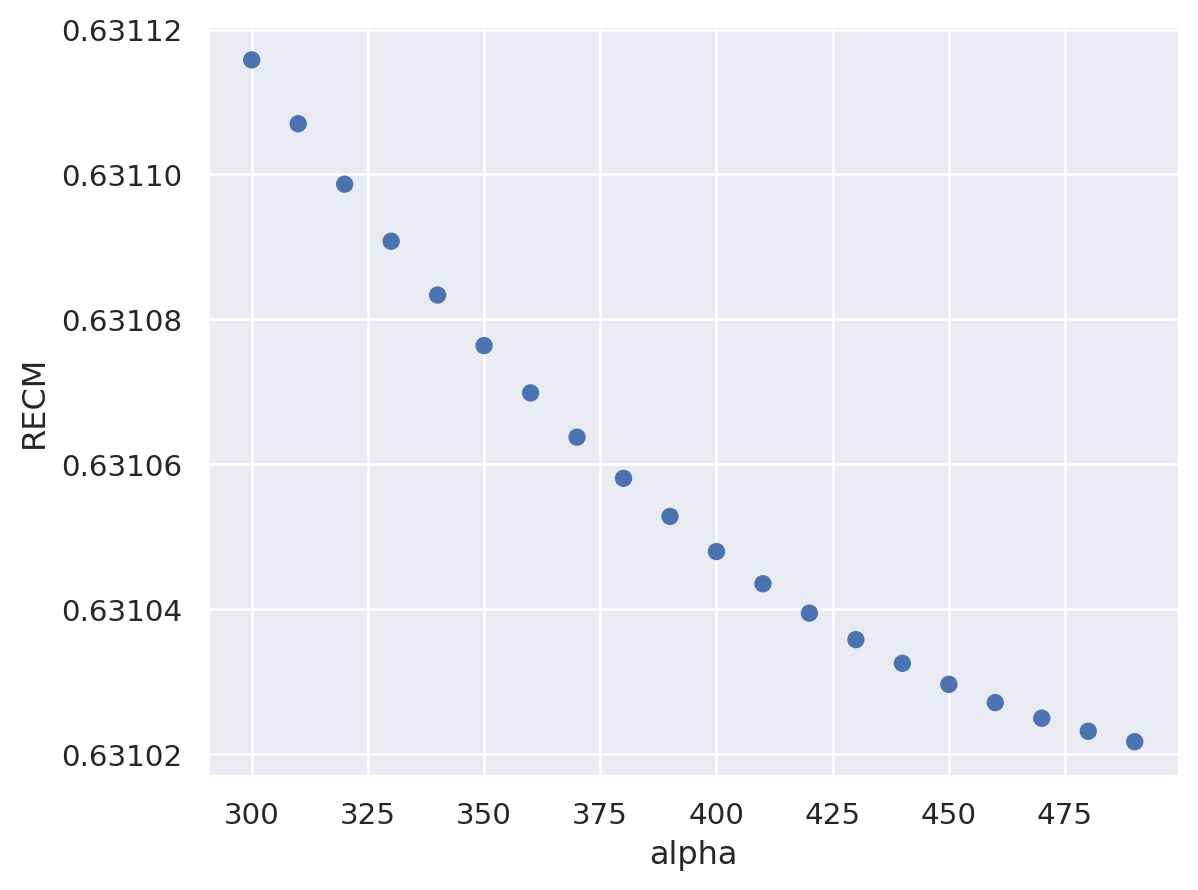

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

In [ ]:
alphas = range(500,1000,20)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo2 = Ridge(alpha = alpha, fit_intercept = True)
    rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo2.fit(X_t, y_t)

        y_pred = modelo2.predict(X_v)
        rmse2[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse2.mean():.8f}")
    error_alphas[counter] = rmse2.mean()

Para alpha = 500.00 la raíz del error cuadrático medio es : 0.63102062
Para alpha = 520.00 la raíz del error cuadrático medio es : 0.63101946
Para alpha = 540.00 la raíz del error cuadrático medio es : 0.63101962
Para alpha = 560.00 la raíz del error cuadrático medio es : 0.63102107
Para alpha = 580.00 la raíz del error cuadrático medio es : 0.63102378
Para alpha = 600.00 la raíz del error cuadrático medio es : 0.63102769
Para alpha = 620.00 la raíz del error cuadrático medio es : 0.63103277
Para alpha = 640.00 la raíz del error cuadrático medio es : 0.63103900
Para alpha = 660.00 la raíz del error cuadrático medio es : 0.63104634
Para alpha = 680.00 la raíz del error cuadrático medio es : 0.63105474
Para alpha = 700.00 la raíz del error cuadrático medio es : 0.63106420
Para alpha = 720.00 la raíz del error cuadrático medio es : 0.63107466
Para alpha = 740.00 la raíz del error cuadrático medio es : 0.63108611
Para alpha = 760.00 la raíz del error cuadrático medio es : 0.63109852
Para a

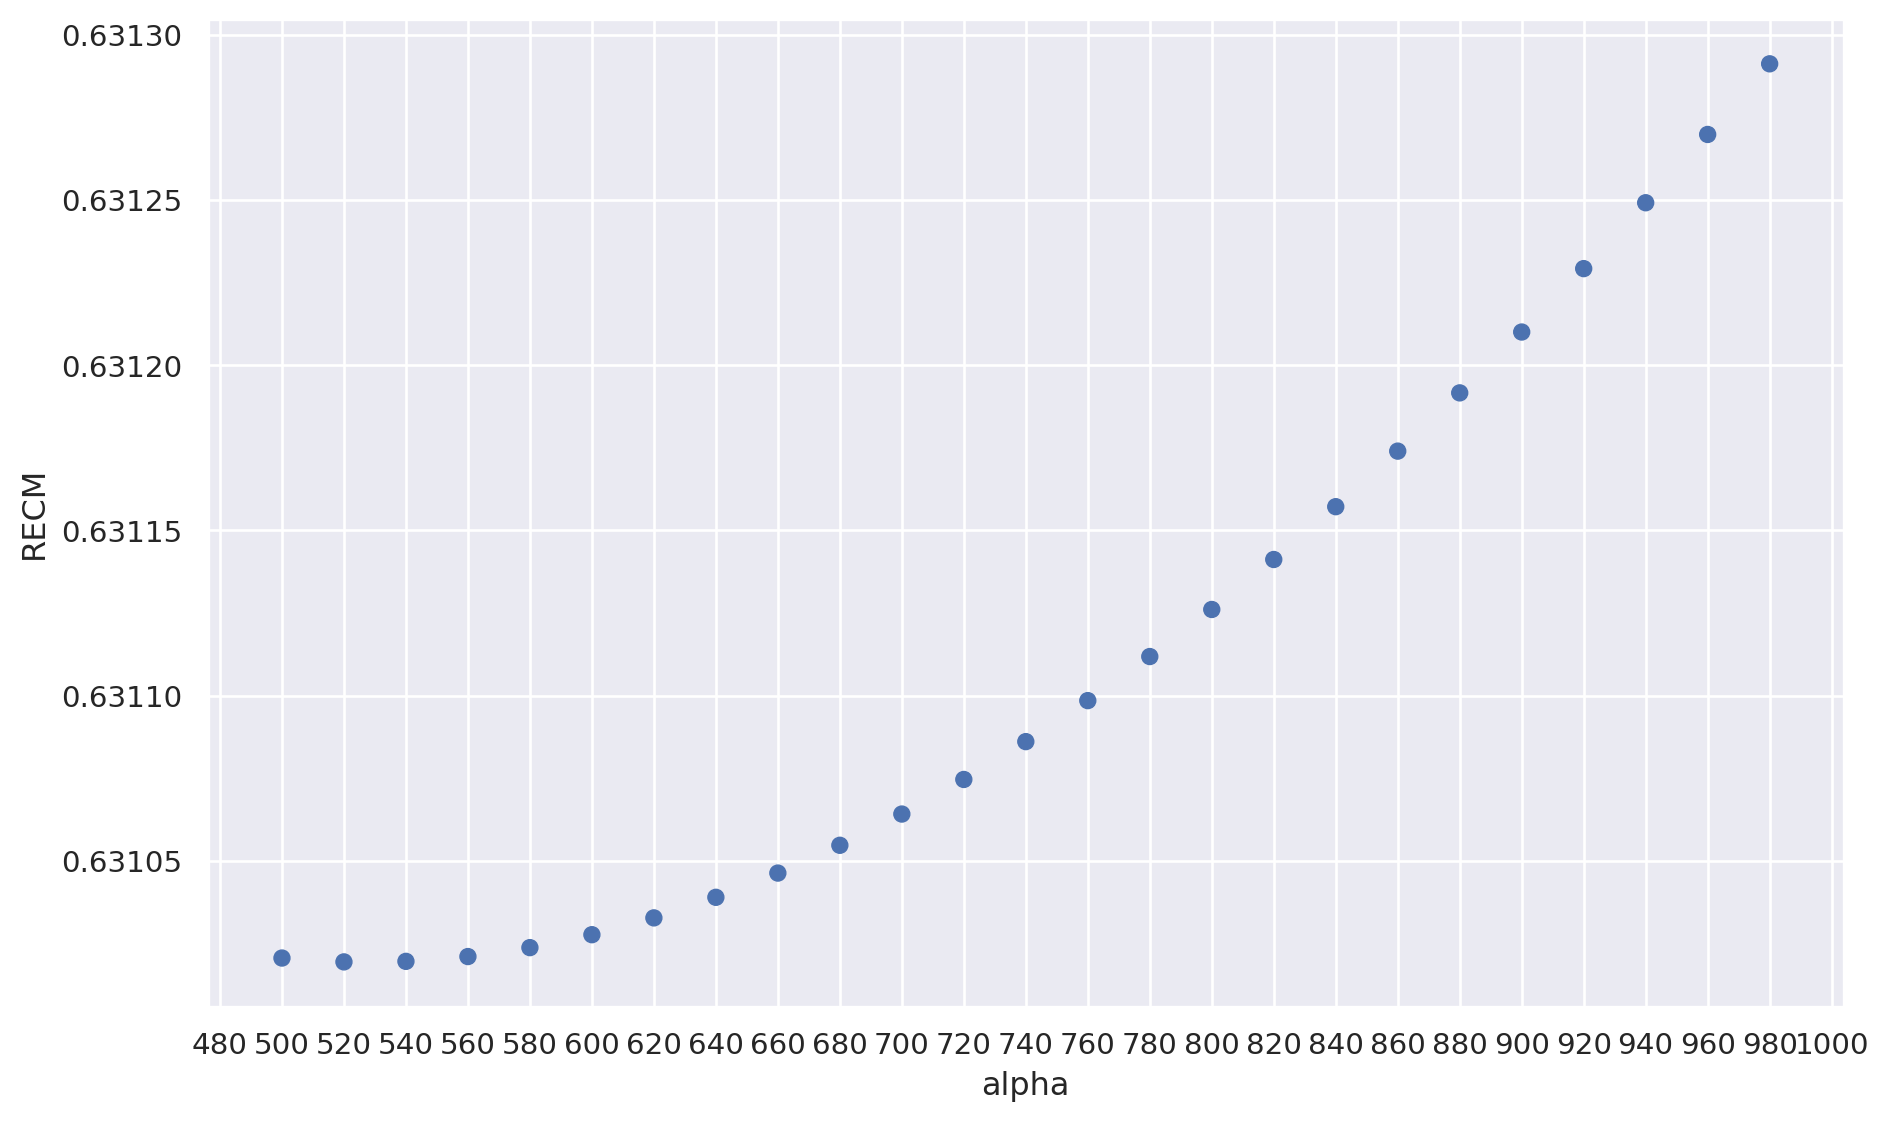

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
    .scale(x=so.Continuous().tick(every=20))
    .layout(size=(10, 6))
)

Encontramos que el alpha óptimo es 520

### Modelo 3: multivariado lineal usando variables seleccionadas

Para el último modelo vamos a probar un modelo lineal multivariado, pero seleccionando columnas que creemos que pueden modelar bien el ingreso de una persona.

In [ ]:
datos_limpios_aux.columns #vemos las columnas que tenia datos limpios antes de pasar a dummies (ej 7)

Index(['EMPLEO', 'REGION', 'MAS_500', 'CH04', 'CH03', 'CH06', 'CH07', 'CH09',
       'CH10', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'SECTOR', 'PP02B',
       'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7',
       'PP02C8', 'PP02D', 'PP02F', 'PP02G', 'PP02H', 'PP02I', 'PP03C', 'PP03D',
       'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP04A', 'PP04A1', 'PP04B1',
       'PP04B2', 'PP04B3_ANO', 'PP04C', 'PP03I', 'PP03J', 'PP03K', 'INTENSI',
       'PP04G', 'P47T'],
      dtype='object')

In [ ]:
datos_limpios_aux["CH09"].value_counts()

,count
CH09,
1,23401
2,272
9,1


Nos quedamos con las siguientes columnas:

EMPLEO
    
REGION

CH04 (Sexo)
    
CH06 (Edad)
    
NIVEL_ED
   
CAT_OCUP

SECTOR (Formal, informal, hogares)

PP03D (Cantidad de ocupaciones)

PP3E_TOT (Horas trabajadas actividad principal)

PP3F_TOT (Horas trabajadas en otras actividades)

PP04A (Sector empresa (ACT PR))

PP04C (Cantidad de trabajadores empresa (ACT PR))

PP04B3_ANO (Antigüedad (ACT PR))

PP04G (En que lugar realiza sus tareas (ACT PR))

In [ ]:
columnas_importantes = [
    "EMPLEO","REGION","CH04","CH06",
    "NIVEL_ED","CAT_OCUP","SECTOR","PP03D",
    "PP3E_TOT","PP3F_TOT","PP04A",
    "PP04C","PP04B3_ANO","PP04G","P47T"]
datos_limpios_aux = datos_limpios_aux[columnas_importantes]

reemplazo_7 = [0 if dato==7 else dato for dato in datos_limpios_aux["NIVEL_ED"]]
datos_limpios_aux["NIVEL_ED"] = reemplazo_7
datos_limpios_aux["P47T"] = np.log(datos_limpios_aux["P47T"])
datos_limpios = datos_limpios[datos_limpios["PP04C"]!=99]

Convertimos a dummies las que son categóricas:

In [ ]:
datos_limpios_aux = pd.get_dummies(
    datos_limpios_aux,
    columns=["REGION", "CAT_OCUP", "PP03D", "PP04A", "PP04G"],
    dtype=int
)

Ahora vamos a hacer un modelo con estas variables, para ver su desempeño frente a los modelos que consideraban todas las variables.

In [ ]:
df_train, df_test = train_test_split(datos_limpios_aux, test_size=0.2, random_state=42)

y_train, X_train = model_matrix('P47T ~ . - 1 - P47T',df_train)
y_test, X_test = model_matrix('P47T ~ . - 1 - P47T',df_test)

y_train = y_train.iloc[:,0]
y_test = y_test.iloc[:,0]

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #ajustamos con los datos de entrenamiento y entrenamos con los de testeo, para no sobreescribir el ajuste

cv = KFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
modelo3 = LinearRegression(fit_intercept = True)
rmse3 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

ind = 0

for train_index, val_index in cv.split(X_train_scaled):
    X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
    modelo3.fit(X_t, y_t)

    y_pred = modelo3.predict(X_v)
    rmse3[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
    ind = ind + 1

print(f"La raíz del error cuadrático medio es : {rmse3.mean():.7f}")

La raíz del error cuadrático medio es : 0.6694874


En el modelo lineal que usaba todas las variables conseguimos un RECM de 0.63 aproximadamente, y ahora seleccionando variables que parecerían explicar bien el ingreso, un RECM de 0.67, lo cual es un buen resultado considerando que se eliminaron muchas variables.

Bonus:

### Modelo 4: multivariado lineal Ridge usando columnas seleccionadas

In [ ]:
alphas = [0.1,0.25,0.5,1,2,4,8,10,15,20,30,40,50]
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo4 = Ridge(alpha = alpha, fit_intercept = True)
    rmse4 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo4.fit(X_t, y_t)

        y_pred = modelo4.predict(X_v)
        rmse4[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse4.mean():.7f}")

    error_alphas[counter] = rmse4.mean()

Para alpha = 0.10 la raíz del error cuadrático medio es : 0.6694870
Para alpha = 0.25 la raíz del error cuadrático medio es : 0.6694864
Para alpha = 0.50 la raíz del error cuadrático medio es : 0.6694855
Para alpha = 1.00 la raíz del error cuadrático medio es : 0.6694835
Para alpha = 2.00 la raíz del error cuadrático medio es : 0.6694797
Para alpha = 4.00 la raíz del error cuadrático medio es : 0.6694722
Para alpha = 8.00 la raíz del error cuadrático medio es : 0.6694576
Para alpha = 10.00 la raíz del error cuadrático medio es : 0.6694505
Para alpha = 15.00 la raíz del error cuadrático medio es : 0.6694334
Para alpha = 20.00 la raíz del error cuadrático medio es : 0.6694172
Para alpha = 30.00 la raíz del error cuadrático medio es : 0.6693872
Para alpha = 40.00 la raíz del error cuadrático medio es : 0.6693602
Para alpha = 50.00 la raíz del error cuadrático medio es : 0.6693361


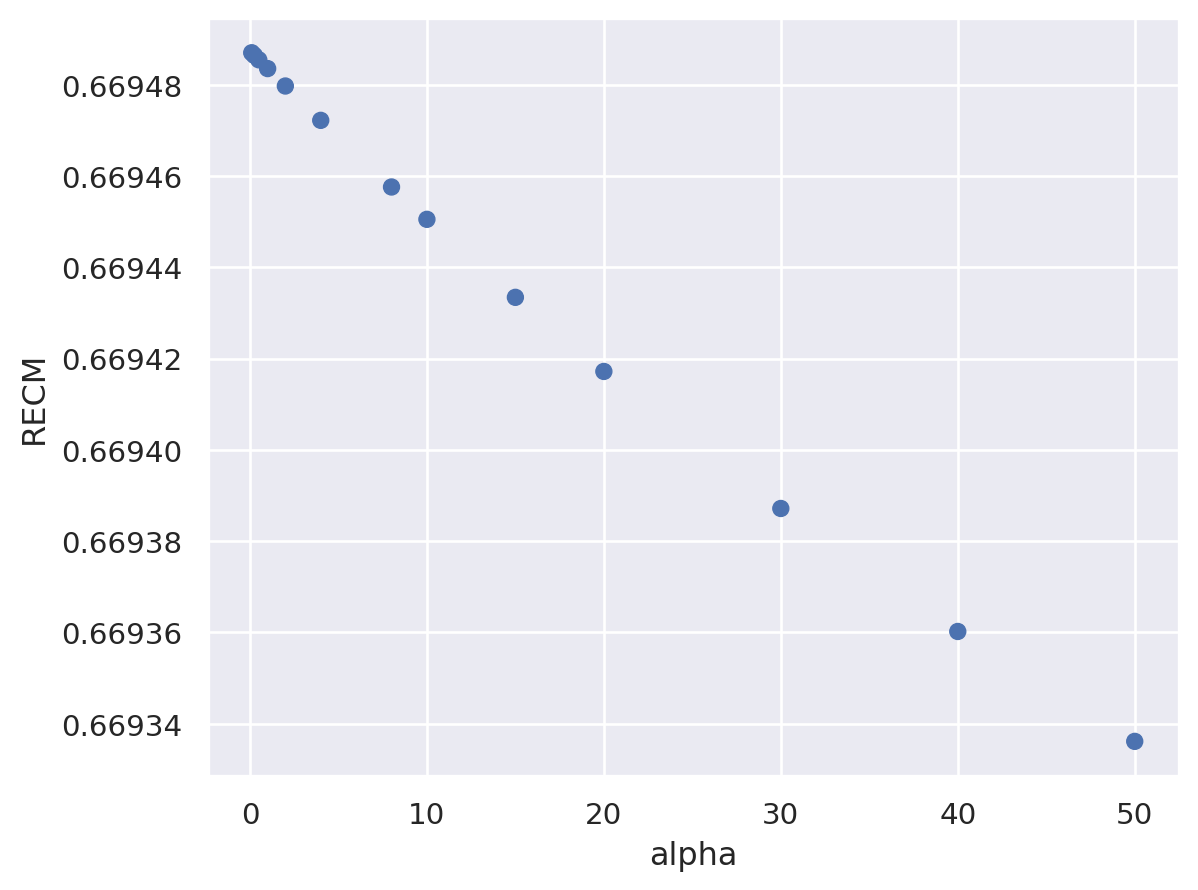

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Probamos col alphas mayores:

In [ ]:
alphas = range(50,100,5)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo4 = Ridge(alpha = alpha, fit_intercept = True)
    rmse4 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo4.fit(X_t, y_t)

        y_pred = modelo4.predict(X_v)
        rmse4[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse4.mean():.7f}")

    error_alphas[counter] = rmse4.mean()

Para alpha = 50.00 la raíz del error cuadrático medio es : 0.6693361
Para alpha = 55.00 la raíz del error cuadrático medio es : 0.6693251
Para alpha = 60.00 la raíz del error cuadrático medio es : 0.6693147
Para alpha = 65.00 la raíz del error cuadrático medio es : 0.6693050
Para alpha = 70.00 la raíz del error cuadrático medio es : 0.6692958
Para alpha = 75.00 la raíz del error cuadrático medio es : 0.6692873
Para alpha = 80.00 la raíz del error cuadrático medio es : 0.6692793
Para alpha = 85.00 la raíz del error cuadrático medio es : 0.6692719
Para alpha = 90.00 la raíz del error cuadrático medio es : 0.6692650
Para alpha = 95.00 la raíz del error cuadrático medio es : 0.6692586


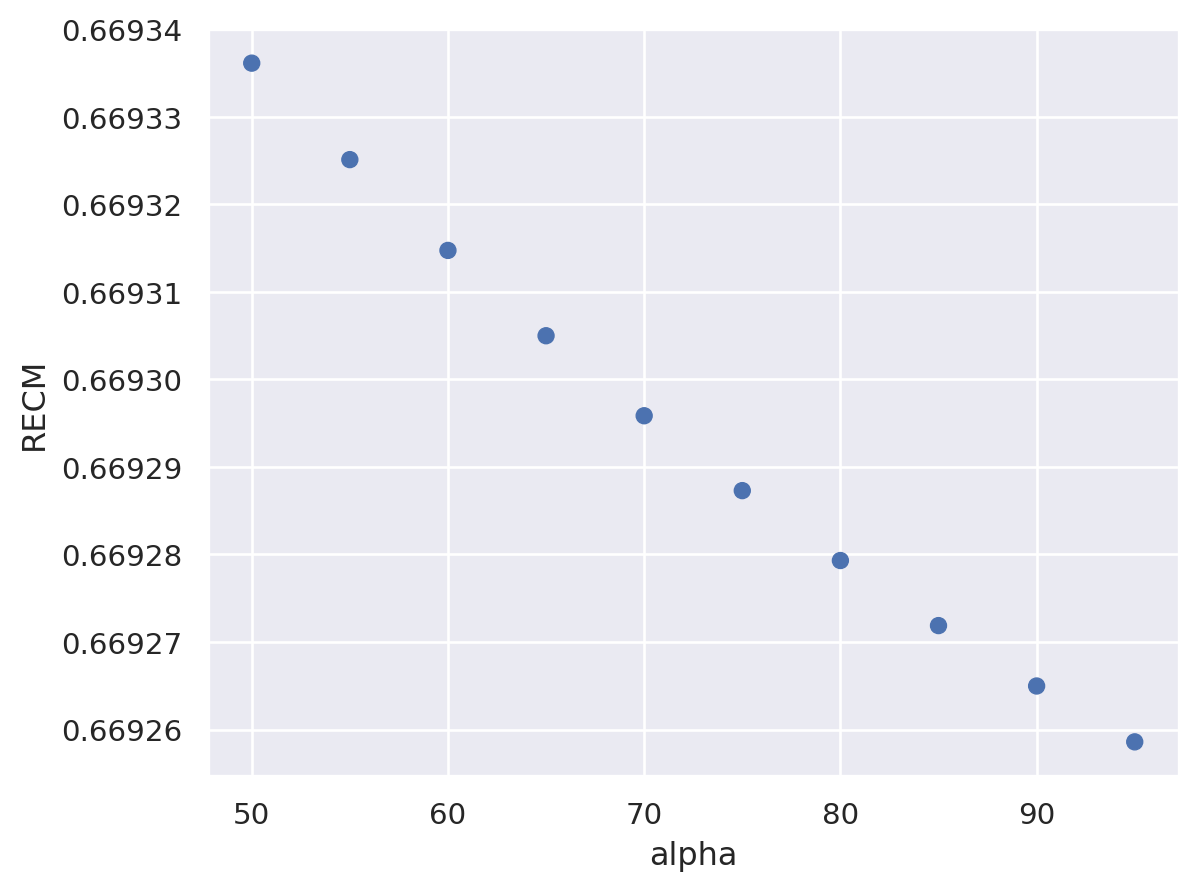

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Seguimos viendo alphas mayores:

In [ ]:
alphas = range(100,300,10)
error_alphas = np.zeros(len(alphas))

for counter, alpha in enumerate(alphas):
    modelo4 = Ridge(alpha = alpha, fit_intercept = True)
    rmse4 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

    ind = 0

    for train_index, val_index in cv.split(X_train_scaled):
        X_t, X_v, y_t, y_v = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
        modelo4.fit(X_t, y_t)

        y_pred = modelo4.predict(X_v)
        rmse4[ind] = np.sqrt(mean_squared_error(y_v, y_pred))
        ind = ind + 1

    print(f"Para alpha = {alpha:.2f} la raíz del error cuadrático medio es : {rmse4.mean():.8f}")
    error_alphas[counter] = rmse4.mean()

Para alpha = 100.00 la raíz del error cuadrático medio es : 0.66925271
Para alpha = 110.00 la raíz del error cuadrático medio es : 0.66924239
Para alpha = 120.00 la raíz del error cuadrático medio es : 0.66923392
Para alpha = 130.00 la raíz del error cuadrático medio es : 0.66922718
Para alpha = 140.00 la raíz del error cuadrático medio es : 0.66922208
Para alpha = 150.00 la raíz del error cuadrático medio es : 0.66921853
Para alpha = 160.00 la raíz del error cuadrático medio es : 0.66921645
Para alpha = 170.00 la raíz del error cuadrático medio es : 0.66921576
Para alpha = 180.00 la raíz del error cuadrático medio es : 0.66921640
Para alpha = 190.00 la raíz del error cuadrático medio es : 0.66921830
Para alpha = 200.00 la raíz del error cuadrático medio es : 0.66922139
Para alpha = 210.00 la raíz del error cuadrático medio es : 0.66922563
Para alpha = 220.00 la raíz del error cuadrático medio es : 0.66923096
Para alpha = 230.00 la raíz del error cuadrático medio es : 0.66923733
Para a

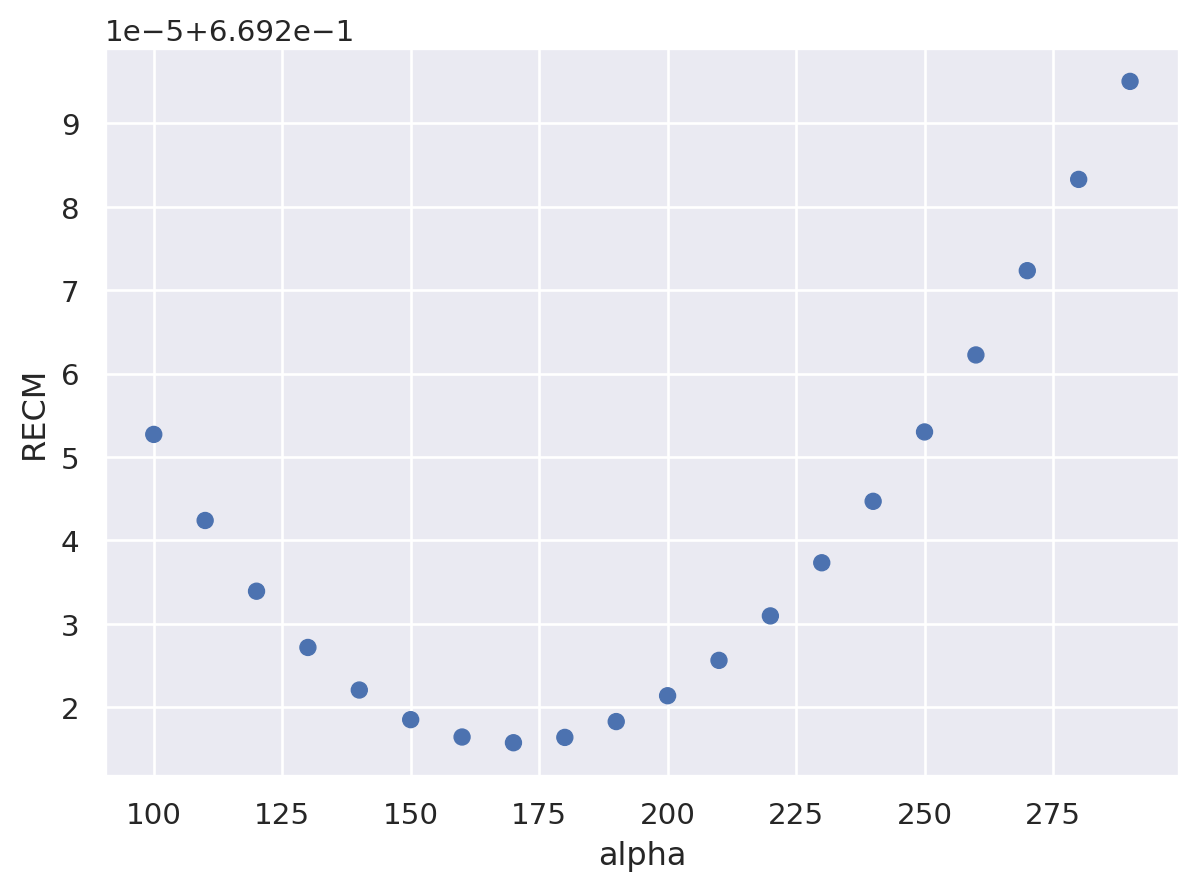

In [ ]:
(
    so.Plot(x = alphas, y = error_alphas)
    .add(so.Dot(color = "b"))
    .label(x="alpha", y="RECM")
)

Ahora el mejor alpha es 170.

## Ejercicio 21

Usamos dos modelos de regresión Ridge, que tenían a alpha como hiperparámetro, y lo seleccionamos buscando el que minimizaba el RECM en la validación.

## Ejercicio 22

Los resultados fueron los siguientes:

RECM:

- Modelo 1: 0.6282573

- Modelo 2: 0.62814167

- Modelo 3: 0.6694874

- Modelo 4: 0.66921576

Entre los modelos  1 y 2, y 3 y 4 elegimos como candidato a mejor modelo al 2 y 4, ya que mejoran levemente a su correspondiente modelo sin hiperparámetro alpha.

Vemos cual es la diferencia porcentual entre el 2 y 4:

In [ ]:
0.66921576/0.62814167*100

106.53898506685601

Vemos que el modelo 4 tiene un 6,54% más de RECM que el modelo 2, pero considerando que es mucho mas simple, lo vamos a elegir como el mejor modelo de los 4.

Calculamos su RECM en los datos de prueba, que son los que no utilizamos todavía.

No redefinimos X ni y porque son las mismas matrices que usamos para los modelos 3 y 4.

In [ ]:
alpha_optimo = 170
modelo4 = Ridge(alpha = alpha_optimo, fit_intercept = True)
modelo4.fit(X_train_scaled, y_train)
y_pred = modelo4.predict(X_test_scaled)
rmse4 = np.sqrt(mean_squared_error(y_test, y_pred))
rmse4

np.float64(0.6706805023227053)

Obtuvimos, para el mejor modelo, una RECM de 0.67 aproximadamente.

## Ejercicio 23

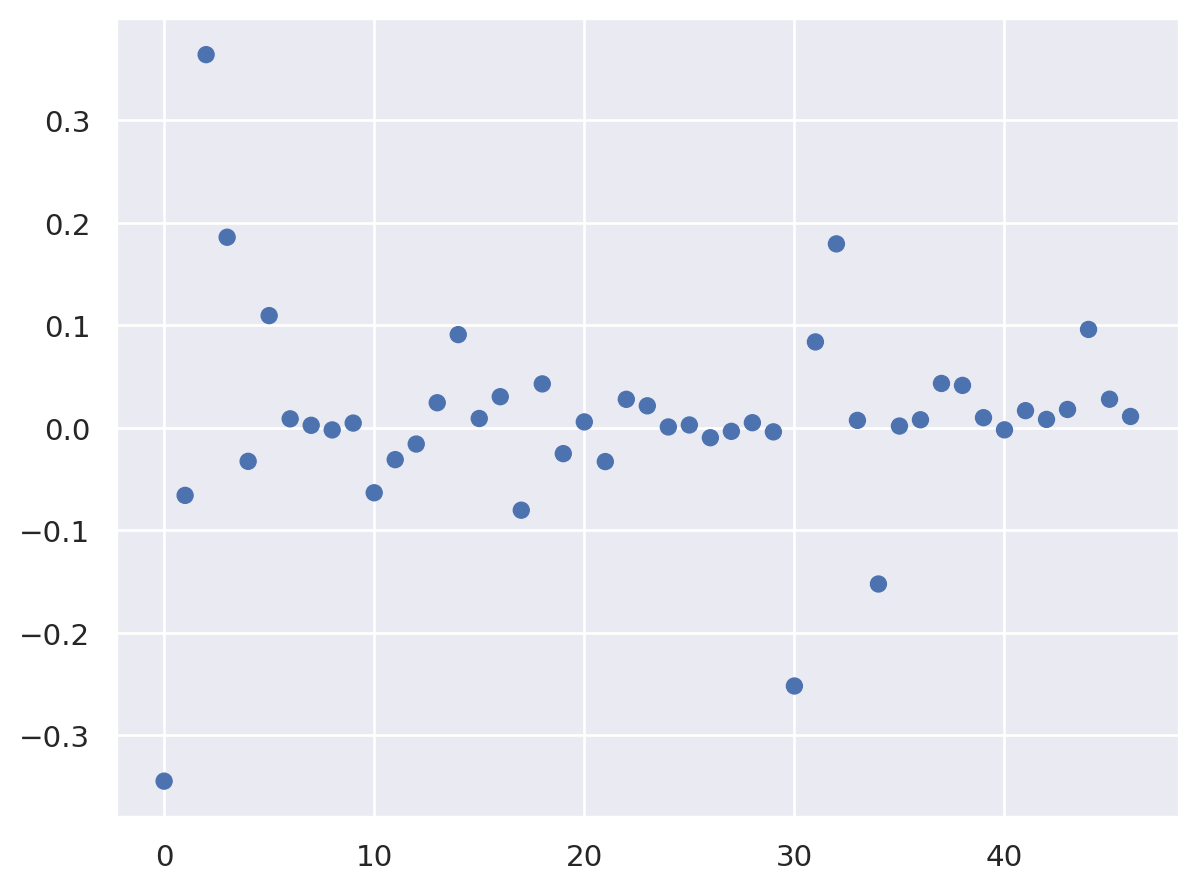

In [ ]:
(
    so.Plot(x = np.arange(datos_limpios_aux.shape[1]))
    .add(so.Dot(color = "b"), y = modelo4.coef_)
)

In [ ]:
cols = X_train_scaled.columns
coefs = modelo4.coef_
columnas_coeficientes = pd.DataFrame({"columnas":cols,"coeficientes":coefs})

In [ ]:
columnas_coeficientes.sort_values(by="coeficientes",ascending=False)

,columnas,coeficientes
2,CH06,0.363840
3,NIVEL_ED,0.185796
32,PP04A_2.0,0.179316
5,PP3E_TOT,0.109364
44,PP04G_11.0,0.095896
14,REGION_44,0.090847
31,PP04A_1.0,0.083718
37,PP04G_4.0,0.043219
18,CAT_OCUP_3,0.042781
38,PP04G_5.0,0.041322


Podemos identificar tres variables que son las que tienen un coeficiente mayor, asi que como indica la consigna, se pueden tomar como las mas representativas para este análisis, y son:

CH06 (Edad)

NIVEL_ED

PP04A_2.0 (Sector de la empresa, la opción 2 indica que es privada)

En la columna PP04A había un problema, como se vió en el ejercicio 7, y es que tiene muchos valores con el número 0, y este no es un valor que podía tomar esta columna segun el INDEC (solo podía valer 1,2 o 3). Además de esto, se puede ver que justo ese valor, tiene uno de los coeficientes mas chicos, asi que es probable que se contrarresten entre sí, y al no entender bien qué significa este valor, nos puede alterar la interpretación del resultado.

Por lo tanto, vamos a reemplazar esa variable por la que le seguía en la lista, que es PP3E_TOT.

Variables seleccionadas:

CH06 (Edad)

NIVEL_ED

PP3E_TOT (Horas semanales trabajadas en la ocupación principal)

Como conclusión, creemos que el modelo nos arrojó un buen resultado, ya que es esperable que la edad, el nivel educativo y las horas trabajadas (y si se quiere sumar el sector de la empresa), expliquen en buena medida el ingreso de un trabajador.